# Spaceship Titanic: Verideki Hikâye

2912 yılında, dünyadan ayrılan bir uzay gemisi, Spaceship Titanic, bir uzay-zaman anomalisine çarptı ve yolcularının neredeyse yarısı başka bir boyuta taşındı.

**Soru:** hangi yolcular taşındı (`Transported`) ve bir model bunun nedenini öğrenebilir mi?

| | Titanic | Spaceship Titanic |
|---|---|---|
| Olay | 1912, gemi buzdağına çarpıp batıyor | 2912, uzay gemisi bir uzay-zaman anomalisine çarpıyor |
| Yolculara ne oluyor? | Bir kısmı ölüyor, bir kısmı kurtuluyor | Yaklaşık yarısı başka bir boyuta taşınıyor |
| Tahmin | `Survived`: hayatta kaldı mı? | `Transported`: taşındı mı? |
| Kayıtlar | Yaş, cinsiyet, sınıf, bilet | Gezegen, kabin, uyku durumu, harcamalar |

Kurtarma ekipleri geminin hasarlı bilgisayarından kurtarılan kayıtlarla kimin kaybolduğunu bulmaya çalışıyor. Bizim işimiz de bu: her yolcu için evet/hayır tahmini.

**Önemli fark:** Titanic gerçek bir olaydı; "önce kadınlar ve çocuklar" gibi hipotezlerimiz tarihten geliyordu. Spaceship Titanic ise kurgusal, anomalinin nasıl çalıştığını kimse bilmiyor. Bu yüzden kuralları tarihten değil **veriden** öğreneceğiz.

## Bölüm 1: Veriyi Tanımak

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["axes.grid.axis"] = "y"

# Grafik renkleri: mavi = taşınmadı, turuncu = taşındı, gri = tek ölçü
TARGET_COLORS = {False: "#2a78d6", True: "#eb6834"}
TARGET_LABELS = {False: "Taşınmadı", True: "Taşındı"}
NEUTRAL = "#6b6a65"
INK = "#52514e"
RATE_LABEL = "Taşınma oranı"


def label_bars(ax, fmt="{:.0%}"):
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9, color=INK)


def rate_bar(ax, rates, title, xlabel):
    ax.bar(rates.index.astype(str), rates.values, color=NEUTRAL, width=0.6)
    ax.axhline(train_raw["Transported"].mean(), color=INK, linestyle="--", linewidth=1)
    label_bars(ax)
    ax.set(ylim=(0, 1.05), title=title, xlabel=xlabel, ylabel=RATE_LABEL)

# Yerel: dataset/  ·  Kaggle: /kaggle/input/...
KAGGLE_INPUT = Path("/kaggle/input")
DATA_DIR = next(KAGGLE_INPUT.rglob("train.csv")).parent if KAGGLE_INPUT.exists() else Path("dataset")

train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")
print(f"Veri: {DATA_DIR}")
train_raw.head()

Veri: dataset


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00,False,0.00,0.00,0.00,0.00,0.00,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00,False,109.00,9.00,25.00,549.00,44.00,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00,True,43.00,"3,576.00",0.00,"6,715.00",49.00,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.00,False,0.00,"1,283.00",371.00,"3,329.00",193.00,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.00,False,303.00,70.00,151.00,565.00,2.00,Willy Santantines,True


### 1.1 Satır ve sütun sayısı

In [2]:
pd.DataFrame(
    {"satır": [len(train_raw), len(test_raw)], "sütun": [train_raw.shape[1], test_raw.shape[1]]},
    index=["train", "test"],
)

,satır,sütun
train,8693,14
test,4277,13


In [3]:
# Test'te olmayan tek sütun hedef olmalı
set(train_raw.columns) - set(test_raw.columns)

{'Transported'}

### 1.2 Sütunlar ne anlama geliyor?

| Sütun | Anlam |
|---|---|
| `PassengerId` | `gggg_pp`: `gggg` yolcunun seyahat ettiği grup, `pp` grup içindeki sırası. Grup çoğu zaman aile ama her zaman değil |
| `HomePlanet` | Yolcunun ayrıldığı gezegen (genelde kalıcı olarak yaşadığı yer) |
| `CryoSleep` | Yolculuk boyunca dondurulmuş uykuda mı? Uyuyanlar kabinlerinden çıkmaz |
| `Cabin` | `deck/num/side`: güverte / kabin numarası / taraf (`P` = Port, `S` = Starboard) |
| `Destination` | Yolcunun ineceği gezegen |
| `Age` | Yaş |
| `VIP` | VIP hizmeti için ödeme yaptı mı? |
| `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` | Geminin lüks hizmetlerine yapılan harcama |
| `Name` | Ad ve soyad |
| `Transported` | **Hedef:** başka bir boyuta taşındı mı? |

### 1.3 Veri tipleri

In [4]:
def column_overview(df):
    return pd.DataFrame({
        "tip": df.dtypes.astype(str),
        "dolu": df.notna().sum(),
        "eksik": df.isna().sum(),
        "benzersiz": df.nunique(),
        "örnek": df.apply(lambda s: s.dropna().iloc[0]),
    })

column_overview(train_raw)

,tip,dolu,eksik,benzersiz,örnek
PassengerId,object,8693,0,8693,0001_01
HomePlanet,object,8492,201,3,Europa
CryoSleep,object,8476,217,2,False
Cabin,object,8494,199,6560,B/0/P
Destination,object,8511,182,3,TRAPPIST-1e
Age,float64,8514,179,80,39.00
VIP,object,8490,203,2,False
RoomService,float64,8512,181,1273,0.00
FoodCourt,float64,8510,183,1507,0.00
ShoppingMall,float64,8485,208,1115,0.00


In [5]:
# object tipindeki sütunlar gerçekte ne tutuyor?
for col in ["CryoSleep", "VIP"]:
    print(col, train_raw[col].map(type).value_counts(dropna=False).to_dict())

CryoSleep {<class 'bool'>: 8476, <class 'float'>: 217}
VIP {<class 'bool'>: 8490, <class 'float'>: 203}


**Tip dönüşümü:** `CryoSleep` ve `VIP` True/False değerleri ile eksik değerler (`NaN`) taşıdığı için pandas bunları `object` olarak okudu. Eksik değeri koruyan `boolean` tipine çeviriyoruz. Metin sütunları (`HomePlanet`, `Destination`) `category` oluyor. `Cabin`, `PassengerId` ve `Name` birleşik bilgi taşıyor; bunları ayrıştırmayı ön işleme adımına bırakıyoruz.

In [6]:
BOOL_COLS = ["CryoSleep", "VIP"]
CAT_COLS = ["HomePlanet", "Destination"]
SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUM_COLS = ["Age"] + SPEND_COLS


def convert_types(df):
    df = df.copy()
    df[BOOL_COLS] = df[BOOL_COLS].astype("boolean")
    df[CAT_COLS] = df[CAT_COLS].astype("category")
    return df


train = convert_types(train_raw)
test = convert_types(test_raw)
pd.DataFrame({"önce": train_raw.dtypes.astype(str), "sonra": train.dtypes.astype(str)})

,önce,sonra
PassengerId,object,object
HomePlanet,object,category
CryoSleep,object,boolean
Cabin,object,object
Destination,object,category
Age,float64,float64
VIP,object,boolean
RoomService,float64,float64
FoodCourt,float64,float64
ShoppingMall,float64,float64


### 1.4 Tekrar eden kayıtlar

In [7]:
full = pd.concat([train.drop(columns="Transported"), test], keys=["train", "test"])

pd.Series({
    "tamamen aynı satır (train)": train.duplicated().sum(),
    "tekrar eden PassengerId (train + test)": full["PassengerId"].duplicated().sum(),
    "ID hariç aynı satır (train + test)": full.drop(columns="PassengerId").duplicated().sum(),
    "tekrar eden isim (train + test, dolu)": full["Name"].dropna().duplicated().sum(),
})

tamamen aynı satır (train)                 0
tekrar eden PassengerId (train + test)     0
ID hariç aynı satır (train + test)         0
tekrar eden isim (train + test, dolu)     47
dtype: int64

In [8]:
# Aynı isimli yolcular aynı kişi mi?
same_name = full[full["Name"].notna() & full["Name"].duplicated(keep=False)].sort_values("Name")
same_name.head(6)

PassengerId HomePlanet  CryoSleep    Cabin  Destination   Age  \
train 2404     2589_01     Europa       True   C/91/P  TRAPPIST-1e 26.00   
test  593      1219_02     Europa       True   B/52/S  55 Cancri e 23.00   
train 6296     6665_01     Europa       True  B/222/P  55 Cancri e 17.00   
      7270     7775_01     Europa      False  C/253/P  55 Cancri e 28.00   
      2930     3176_01     Europa      False  E/196/P  TRAPPIST-1e 77.00   
      476      0512_02     Europa       True   D/18/S  TRAPPIST-1e 55.00   

              VIP  RoomService  FoodCourt  ShoppingMall    Spa   VRDeck  \
train 2404  False         0.00       0.00          0.00   0.00     0.00   
test  593   False         0.00       0.00          0.00   0.00     0.00   
train 6296  False         0.00       0.00          0.00   0.00     0.00   
      7270  False         7.00     489.00          0.00   4.00 6,027.00   
      2930  False         0.00   9,032.00          0.00 128.00 1,464.00   
      476   False         0.00       0.00          0.00   0.00     0.00   

                          Name  
train 2404      Alasmon Meteet  
test  593       Alasmon Meteet  
train 6296  Alraium Disivering  
      7270  Alraium Disivering  
      2930  Ankalik Nateansive  
      476   Ankalik Nateansive

### 1.5 Eksik veriler

In [9]:
missing = pd.DataFrame({
    "train_eksik": train.isna().sum(),
    "train_%": train.isna().mean() * 100,
    "test_eksik": test.isna().sum(),
    "test_%": test.isna().mean() * 100,
}).drop(index="Transported").astype({"test_eksik": int}).sort_values("train_%", ascending=False)
missing

,train_eksik,train_%,test_eksik,test_%
CryoSleep,217,2.50,93,2.17
ShoppingMall,208,2.39,98,2.29
VIP,203,2.34,93,2.17
HomePlanet,201,2.31,87,2.03
Name,200,2.30,94,2.20
Cabin,199,2.29,100,2.34
VRDeck,188,2.16,80,1.87
FoodCourt,183,2.11,106,2.48
Spa,183,2.11,101,2.36
Destination,182,2.09,92,2.15


In [10]:
# Bir yolcuda kaç sütun eksik?
per_row = pd.DataFrame({
    "train": train.drop(columns="Transported").isna().sum(axis=1).value_counts(),
    "test": test.isna().sum(axis=1).value_counts(),
}).fillna(0).astype(int)
per_row.index.name = "eksik sütun sayısı"
per_row

,train,test
eksik sütun sayısı,,
0,6606,3281
1,1867,879
2,203,113
3,17,4


In [11]:
# Eksik içeren satırları silseydik ne kaybederdik?
dropped = train.dropna()
pd.Series({
    "train satır": len(train),
    "eksiksiz satır": len(dropped),
    "silinecek satır": len(train) - len(dropped),
    "kayıp oranı %": round((1 - len(dropped) / len(train)) * 100, 1),
    "test'te eksik içeren satır": test.isna().any(axis=1).sum(),
}, dtype=object)

train satır                   8693
eksiksiz satır                6606
silinecek satır               2087
kayıp oranı %                24.00
test'te eksik içeren satır     996
dtype: object

### 1.6 Temel istatistikler

In [12]:
num = train[NUM_COLS]
pd.DataFrame({
    "ortalama": num.mean(),
    "medyan": num.median(),
    "std": num.std(),
    "min": num.min(),
    "%25": num.quantile(0.25),
    "%75": num.quantile(0.75),
    "max": num.max(),
    "sıfır %": (num == 0).mean() * 100,
    "çarpıklık": num.skew(),
})

,ortalama,medyan,std,min,%25,%75,max,sıfır %,çarpıklık
Age,28.83,27.00,14.49,0.00,19.00,38.00,79.00,2.05,0.42
RoomService,224.69,0.00,666.72,0.00,0.00,47.00,"14,327.00",64.16,6.33
FoodCourt,458.08,0.00,"1,611.49",0.00,0.00,76.00,"29,813.00",62.76,7.10
ShoppingMall,173.73,0.00,604.70,0.00,0.00,27.00,"23,492.00",64.27,12.63
Spa,311.14,0.00,"1,136.71",0.00,0.00,59.00,"22,408.00",61.24,7.64
VRDeck,304.85,0.00,"1,145.72",0.00,0.00,46.00,"24,133.00",63.21,7.82


In [13]:
# Kategorik ve mantıksal sütunlar: değer dağılımları (%)
for col in CAT_COLS + BOOL_COLS + ["Transported"]:
    print(f"\n{col}")
    print((train[col].value_counts(dropna=False, normalize=True) * 100).round(1).to_string())


HomePlanet
HomePlanet
Earth    52.90
Europa   24.50
Mars     20.20
NaN       2.30

Destination
Destination
TRAPPIST-1e     68.00
55 Cancri e     20.70
PSO J318.5-22    9.20
NaN              2.10

CryoSleep
CryoSleep
False   62.60
True    34.90
<NA>     2.50

VIP
VIP
False   95.40
<NA>     2.30
True     2.30

Transported
Transported
True    50.40
False   49.60


### 1.7 Eksik veriler hakkında iki soru

- **Eksiklik rastgele mi?** Eksik olan ve olmayan yolcuların taşınma oranı aynıysa, eksiklik kendi başına bir ipucu değildir.
- **Eksikler diğer sütunlardan çıkarılabilir mi?** Örneğin uyuyan biri harcama yapamaz; aynı grupta seyahat edenler aynı gezegenden gelir.

### 1.8 Eksiklik taşınmayla ilişkili mi?

In [14]:
rows = []
for col in train.columns.drop(["PassengerId", "Transported"]):
    miss = train[col].isna()
    rows.append({
        "sütun": col,
        "eksik n": miss.sum(),
        "taşınma % (eksik)": train.loc[miss, "Transported"].mean() * 100,
        "taşınma % (dolu)": train.loc[~miss, "Transported"].mean() * 100,
    })
pd.DataFrame(rows).set_index("sütun")

,eksik n,taşınma % (eksik),taşınma % (dolu)
sütun,,,
HomePlanet,201,51.24,50.34
CryoSleep,217,48.85,50.40
Cabin,199,50.25,50.36
Destination,182,50.55,50.36
Age,179,50.28,50.36
VIP,203,51.23,50.34
RoomService,181,45.86,50.46
FoodCourt,183,54.10,50.28
ShoppingMall,208,54.81,50.25


### 1.9 Eksikler diğer sütunlardan çıkarılabilir mi?

Önce birleşik sütunları sadece analiz için ayırıyoruz. Bu ilişkiler hedefi kullanmadığı için train ve test birlikte incelenebilir.

In [15]:
def split_columns(df):
    df = df.copy()
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df.groupby("Group")["PassengerId"].transform("count")
    df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)
    df["Surname"] = df["Name"].str.split().str[-1]
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1, min_count=1)
    return df


full = split_columns(pd.concat([train.drop(columns="Transported"), test], ignore_index=True))


def group_rule(col, key):
    # Aynı key içinde col hep aynı mı? Eksik col, key'den kaç kez doldurulabilir?
    known = full[full[col].notna() & full[key].notna()]
    n_unique = known.groupby(key)[col].nunique()
    multi = known.groupby(key).size() >= 2
    fill_value = known.groupby(key)[col].agg(lambda s: s.mode().iloc[0])
    missing = full[full[col].isna()]
    return {
        "kural": f"{key} → {col}",
        "tutarlılık % (≥2 kişilik gruplar)": (n_unique[multi] == 1).mean() * 100,
        "eksik": len(missing),
        "doldurulabilir": missing[key].map(fill_value).notna().sum(),
    }


pd.DataFrame([
    group_rule("HomePlanet", "Group"),
    group_rule("HomePlanet", "Surname"),
    group_rule("Destination", "Group"),
    group_rule("Cabin", "Group"),
    group_rule("Deck", "Group"),
    group_rule("Side", "Group"),
    group_rule("Surname", "Group"),
    group_rule("VIP", "Group"),
]).set_index("kural")

,tutarlılık % (≥2 kişilik gruplar),eksik,doldurulabilir
kural,,,
Group → HomePlanet,100.00,288,131
Surname → HomePlanet,100.00,288,271
Group → Destination,48.46,274,120
Group → Cabin,67.46,299,137
Group → Deck,67.46,299,137
Group → Side,100.00,299,137
Group → Surname,82.33,294,139
Group → VIP,92.98,296,124


**CryoSleep ↔ harcama:** uyuyan biri harcama yapabilir mi?

In [16]:
pd.crosstab(full["CryoSleep"], full["TotalSpend"] > 0, dropna=False,
            rownames=["CryoSleep"], colnames=["harcama > 0"])

harcama > 0,False,True
CryoSleep,,
False,740,7339
True,4581,0
<NA>,136,174


In [17]:
cryo_missing = full[full["CryoSleep"].isna()]
spend_missing = full[SPEND_COLS].isna().any(axis=1)
pd.Series({
    "CryoSleep eksik": len(cryo_missing),
    "  harcaması > 0 → False": (cryo_missing["TotalSpend"] > 0).sum(),
    "  harcaması 0 → True olabilir": (cryo_missing["TotalSpend"] == 0).sum(),
    "harcama sütunu eksik satır": spend_missing.sum(),
    "  CryoSleep = True → 0": (spend_missing & (full["CryoSleep"] == True)).sum(),
    "  Age < 13 → 0": (spend_missing & (full["Age"] < 13)).sum(),
})

CryoSleep eksik                   310
  harcaması > 0 → False           174
  harcaması 0 → True olabilir     136
harcama sütunu eksik satır       1363
  CryoSleep = True → 0            513
  Age < 13 → 0                    127
dtype: int64

In [18]:
# Harcaması 0 olanların CryoSleep oranı: eksik CryoSleep'i True yapmak ne kadar güvenli?
no_spend = full[full["TotalSpend"] == 0]
(no_spend["CryoSleep"].value_counts(normalize=True, dropna=False) * 100).round(1)

CryoSleep
True    83.90
False   13.60
<NA>     2.50
Name: proportion, dtype: Float64

**Yaş ve harcama:** çocuklar harcama yapıyor mu?

In [19]:
age_band = pd.cut(full["Age"], [-1, 12, 17, 25, 40, 60, 80], labels=["0-12", "13-17", "18-25", "26-40", "41-60", "61+"])
full.groupby(age_band, observed=True).agg(
    n=("Age", "size"),
    harcama_yapan_pct=("TotalSpend", lambda s: (s > 0).mean() * 100),
    medyan_harcama=("TotalSpend", "median"),
)

,n,harcama_yapan_pct,medyan_harcama
Age,,,
0-12,1157,0.00,0.00
13-17,1107,50.95,265.00
18-25,3627,66.64,724.00
26-40,4248,64.41,846.50
41-60,2234,64.37,811.50
61+,327,66.36,870.00


**Güverte → gezegen:** bazı güvertelerde tek gezegenden yolcu mu var?

In [20]:
(pd.crosstab(full["Deck"], full["HomePlanet"], normalize="index") * 100).round(1).assign(
    n=full["Deck"].value_counts()
)

HomePlanet,Earth,Europa,Mars,n
Deck,,,,
A,0.00,100.00,0.00,354
B,0.00,100.00,0.00,1141
C,0.00,100.00,0.00,1102
D,0.00,42.20,57.80,720
E,45.30,15.30,39.40,1323
F,58.60,0.00,41.40,4239
G,100.00,0.00,0.00,3781
T,0.00,100.00,0.00,11


**VIP:** kimler VIP?

In [21]:
full.groupby("HomePlanet", observed=True)["VIP"].agg(VIP_pct=lambda s: s.mean() * 100, n="size").assign(
    VIP_pct=lambda d: d["VIP_pct"].round(2)
).T

HomePlanet,Earth,Europa,Mars
VIP_pct,0.00,5.78,3.43
n,6865,3133,2684


In [22]:
# Age: gezegene ve harcama durumuna göre medyan
full.pivot_table(index="HomePlanet", columns=full["TotalSpend"] > 0, values="Age",
                 aggfunc="median", observed=True).rename(columns={False: "harcama yok", True: "harcama var"})

TotalSpend,harcama yok,harcama var
HomePlanet,,
Earth,19.00,25.00
Europa,30.00,34.00
Mars,25.00,29.00


## Bölüm 2: Kim Taşındı?

Anomali fiziksel bir olay: çarpma anında **nerede olduğun** ve **ne yaptığın** önemli olabilir. Her hipotezi üç adımda inceliyoruz: **sezgi** (neden işe yarayabilir), **veri** (tablo ve grafik), **sonuç** (doğrulandı mı).

Yolcuların %50.4'ü taşındı; grafiklerdeki kesikli çizgi bu ortalama.

### 2.1 Uyanık mı, uykuda mı?

**Sezgi:** CryoSleep'teki yolcu yolculuk boyunca kapsülünde, kabininde kalıyor. Harcama yapan yolcu ise uyanık ve geminin spa, restoran, alışveriş bölümlerinde dolaşıyor. Anomali bu iki grubu farklı etkilemiş olabilir.

In [23]:
spend_total = train[SPEND_COLS].sum(axis=1)
awake = train.assign(
    durum=np.select(
        [train["CryoSleep"].fillna(False).astype(bool), spend_total == 0],
        ["Uykuda", "Uyanık, harcama yok"],
        "Uyanık, harcama var",
    )
)
awake = awake[train["CryoSleep"].notna()]
awake.groupby("durum")["Transported"].agg(taşınma_oranı="mean", kişi="size").sort_values("taşınma_oranı")

,taşınma_oranı,kişi
durum,,
"Uyanık, harcama var",0.30,4921
"Uyanık, harcama yok",0.62,518
Uykuda,0.82,3037


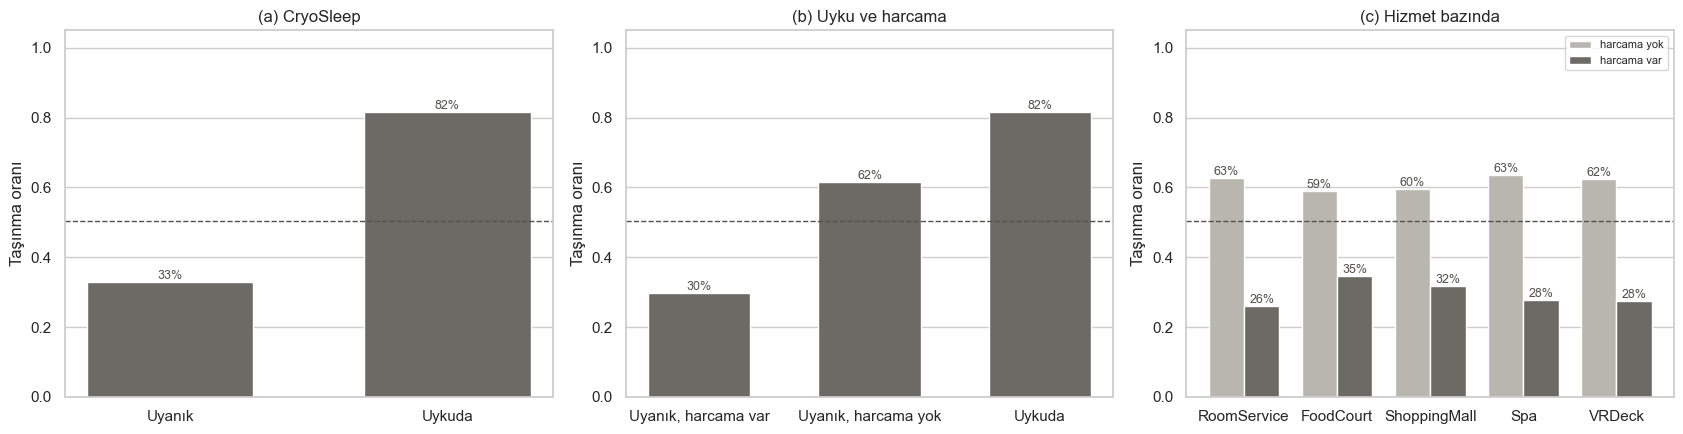

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

rate_bar(axes[0], train.groupby("CryoSleep")["Transported"].mean().rename({False: "Uyanık", True: "Uykuda"}),
         "(a) CryoSleep", "")

order = ["Uyanık, harcama var", "Uyanık, harcama yok", "Uykuda"]
rate_bar(axes[1], awake.groupby("durum")["Transported"].mean().reindex(order), "(b) Uyku ve harcama", "")

# (c) Her hizmet için: harcama yapan ve yapmayanların taşınma oranı
ax = axes[2]
by_service = pd.DataFrame({
    col: train.groupby(train[col] > 0)["Transported"].mean() for col in SPEND_COLS
}).T.rename(columns={False: "harcama yok", True: "harcama var"})
x, width = np.arange(len(SPEND_COLS)), 0.38
ax.bar(x - width / 2, by_service["harcama yok"], width, color="#b8b6ae", label="harcama yok")
ax.bar(x + width / 2, by_service["harcama var"], width, color=NEUTRAL, label="harcama var")
label_bars(ax)
ax.set_xticks(x, SPEND_COLS)
ax.axhline(train["Transported"].mean(), color=INK, linestyle="--", linewidth=1)
ax.set(ylim=(0, 1.05), title="(c) Hizmet bazında", ylabel=RATE_LABEL)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

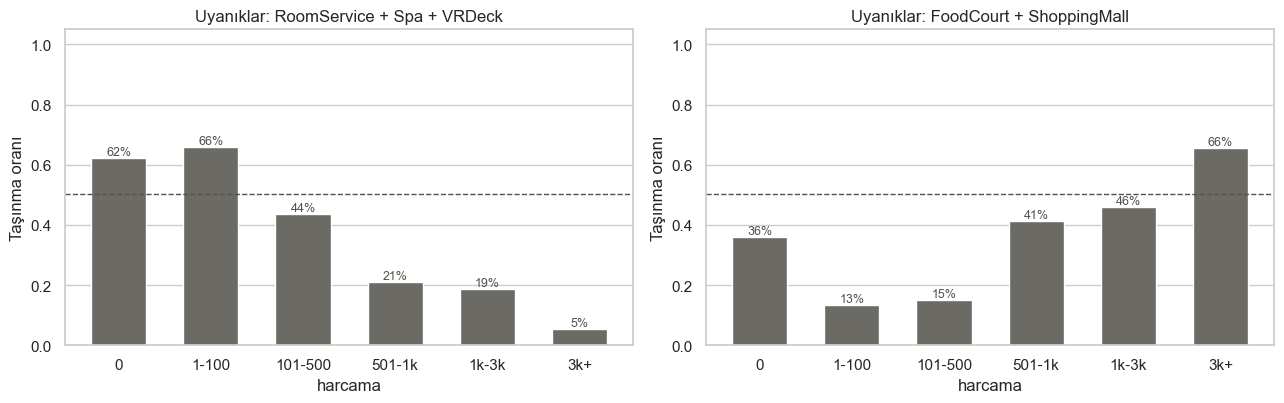

In [25]:
# (d) Uyanıklar içinde: harcama arttıkça taşınma oranı nasıl değişiyor? Hangi hizmet?
awake_spenders = train[(train["CryoSleep"] == False)]
luxury = ["RoomService", "Spa", "VRDeck"]
basic = ["FoodCourt", "ShoppingMall"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, cols, name in [(axes[0], luxury, "RoomService + Spa + VRDeck"), (axes[1], basic, "FoodCourt + ShoppingMall")]:
    total = awake_spenders[cols].sum(axis=1)
    bands = pd.cut(total, [-1, 0, 100, 500, 1000, 3000, np.inf], labels=["0", "1-100", "101-500", "501-1k", "1k-3k", "3k+"])
    rate_bar(ax, awake_spenders.groupby(bands, observed=True)["Transported"].mean(), f"Uyanıklar: {name}", "harcama")
plt.tight_layout()
plt.show()

**Sonuç: doğrulandı, verideki en güçlü sinyal.**

- Uyuyanların **%82**'si taşındı, uyanıkların %33'ü. Titanic'teki "kadınların %74'ü, erkeklerin %19'u" farkının karşılığı bu.
- Uyanık ama hiç harcama yapmayanlar (%62) ikisinin arasında: uyanık olmak tek başına belirleyici değil, gemide ne yaptığın da önemli.
- **Hizmetler aynı davranmıyor.** Oda servisi, Spa ve VR güvertesinde harcama arttıkça taşınma düşüyor (3000 üstünde %5). Yemek alanı ve alışverişte ise ilişki U biçiminde: az harcayanlar %13–15, çok harcayanlar %66. Harcamaları tek bir "toplam" sütununda birleştirmek bu bilgiyi kaybettirir; iki grubu ayrı tutacağız.

### 2.2 Geminin neresindeydi?

**Sezgi:** anomali geminin bir bölgesine çarptıysa, kabin konumu belirleyici olmalı. `Cabin = güverte/numara/taraf`: güverte (A en üst, T en alt), kabin numarası (geminin önünden arkasına), taraf (P = sol/Port, S = sağ/Starboard).

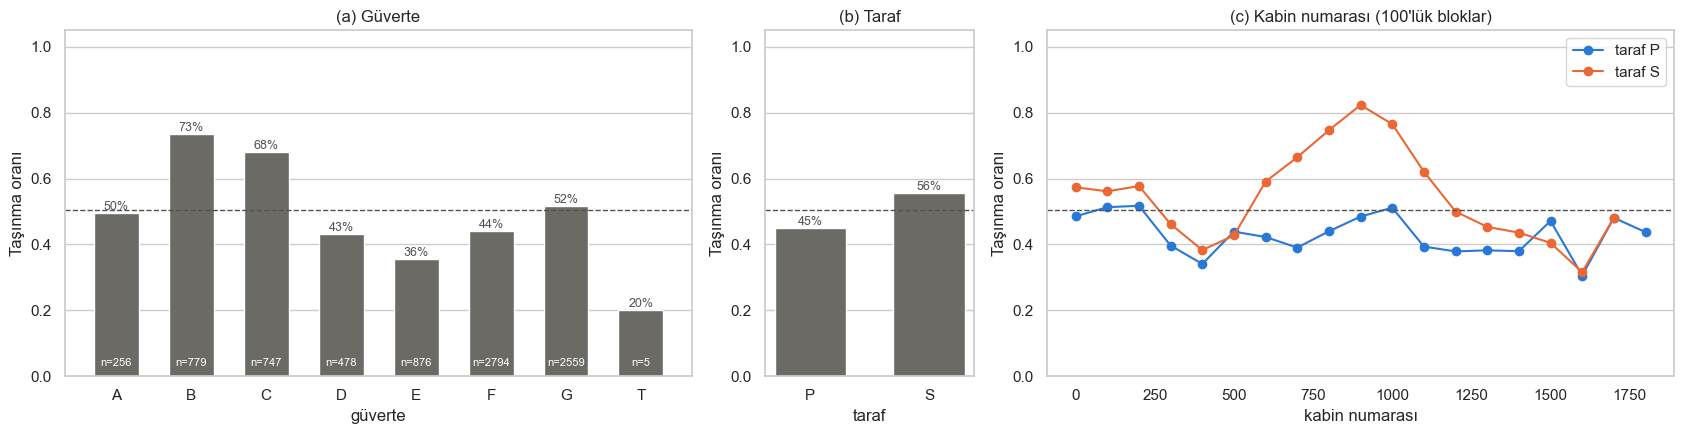

In [26]:
cabin = split_columns(train)
cabin["CabinNum"] = cabin["CabinNum"].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={"width_ratios": [3, 1, 3]})
deck_rates = cabin.groupby("Deck")["Transported"].agg(["mean", "size"])
rate_bar(axes[0], deck_rates["mean"], "(a) Güverte", "güverte")
for i, n in enumerate(deck_rates["size"]):
    axes[0].annotate(f"n={n}", (i, 0.03), ha="center", fontsize=8, color="white")
rate_bar(axes[1], cabin.groupby("Side")["Transported"].mean(), "(b) Taraf", "taraf")

# (c) Kabin numarası boyunca: her 100 kabinlik blok, taraf ayrı
ax = axes[2]
block = (cabin["CabinNum"] // 100 * 100).rename("blok")
for side, color in [("P", "#2a78d6"), ("S", "#eb6834")]:
    rates = cabin[cabin["Side"] == side].groupby(block)["Transported"].mean()
    ax.plot(rates.index, rates.values, marker="o", color=color, label=f"taraf {side}")
ax.axhline(train["Transported"].mean(), color=INK, linestyle="--", linewidth=1)
ax.set(ylim=(0, 1.05), title="(c) Kabin numarası (100'lük bloklar)", xlabel="kabin numarası", ylabel=RATE_LABEL)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Güverte × taraf: iki etki birbirinden bağımsız mı?
(cabin.pivot_table(index="Deck", columns="Side", values="Transported", aggfunc="mean") * 100).round(1)

Side,P,S
Deck,,
A,43.60,54.70
B,67.40,78.40
C,58.10,76.40
D,40.30,46.50
E,34.30,37.10
F,41.10,47.10
G,44.80,58.40
T,25.00,0.00


In [28]:
# Güverte ile CryoSleep ilişkisi: güverte farkı uyuyanların dağılımından mı geliyor?
cabin.groupby(["Deck", "CryoSleep"])["Transported"].mean().unstack().mul(100).round(1).assign(
    uyuyan_pct=cabin.groupby("Deck")["CryoSleep"].mean().mul(100).round(1)
)

CryoSleep,False,True,uyuyan_pct
Deck,,,
A,32.40,94.10,27.20
B,42.20,99.30,55.10
C,46.30,99.30,40.60
D,27.70,99.00,22.20
E,28.60,64.90,19.60
F,30.20,98.50,20.20
G,35.10,65.90,54.10
T,25.00,NaN,0.00


**Sonuç: doğrulandı, konum önemli.**

- **Güverte:** B (%73) ve C (%68) en çok, E (%36) en az taşınan güverte. T'de sadece 5 yolcu var, oran güvenilir değil.
- **Taraf:** sağ taraf (S) %56, sol taraf (P) %45. Fark hemen her güvertede aynı yönde.
- **Kabin numarası:** sağ tarafta 600–1100 numaralı kabinlerde taşınma %80'e çıkıyor, sol tarafta böyle bir tepe yok. Anomalinin geminin sağ tarafında, ortaya yakın bir bölgeye çarptığı düşünülebilir. Kabin numarasını olduğu gibi değil, **bölgelere ayırarak** kullanmak gerekecek.
- **Güverte farkı sadece uyuyanlardan gelmiyor:** B, C, D ve F'de uyuyanların %98–99'u taşınmış, ama E ve G'de sadece %65'i. Uyanık yolcularda da güverteler farklı (D %28, C %46). Yani uyku ve konum birbirini tamamlayan iki ayrı ipucu.

### 2.3 Birlikte seyahat edenler

**Sezgi:** aynı grupta (`PassengerId`'nin ilk 4 hanesi) seyahat edenler çoğu zaman aile ya da arkadaş: yan yana kabinlerde kalıyor, birlikte uyuyor ya da birlikte dolaşıyorlar. Aynı kaderi paylaşmış olabilirler. Soyadı ise grubun ötesinde, akrabalığı gösteriyor.

In [29]:
group = split_columns(train)
group["FamilySize"] = group["Surname"].map(full["Surname"].value_counts())  # train + test'teki aynı soyadlılar

# Grup ve soyadı sayıları hedefi kullanmaz: train + test birlikte sayılıyor
group["GroupSize"] = group["Group"].map(full["Group"].value_counts())
pd.Series({
    "grup sayısı (train + test)": full["Group"].nunique(),
    "yalnız seyahat eden %": (full["GroupSize"] == 1).mean() * 100,
    "hem train hem test'te üyesi olan grup": len(set(split_columns(train)["Group"]) & set(split_columns(test)["Group"])),
}, dtype=object)

grup sayısı (train + test)               9280
yalnız seyahat eden %                   55.09
hem train hem test'te üyesi olan grup       0
dtype: object

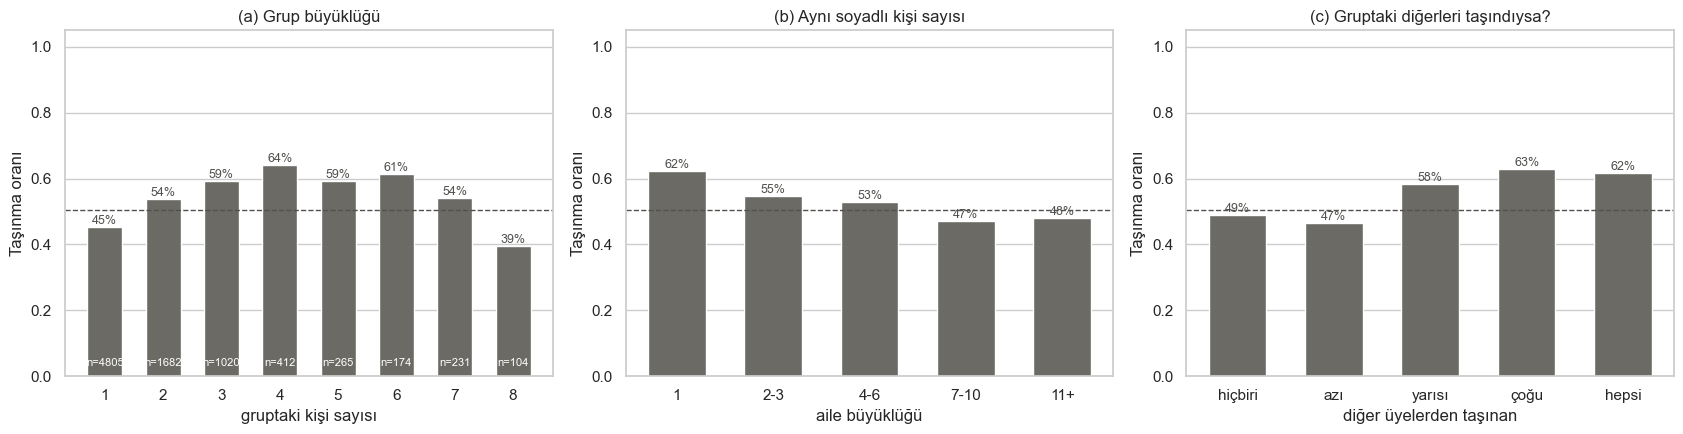

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

gs = group.groupby("GroupSize")["Transported"].agg(["mean", "size"])
rate_bar(axes[0], gs["mean"], "(a) Grup büyüklüğü", "gruptaki kişi sayısı")
for i, n in enumerate(gs["size"]):
    axes[0].annotate(f"n={n}", (i, 0.03), ha="center", fontsize=8, color="white")

fam_band = pd.cut(group["FamilySize"], [0, 1, 3, 6, 10, 20], labels=["1", "2-3", "4-6", "7-10", "11+"])
rate_bar(axes[1], group.groupby(fam_band, observed=True)["Transported"].mean(), "(b) Aynı soyadlı kişi sayısı", "aile büyüklüğü")

# (c) Gruptaki diğer üyelerin taşınma oranı → bu yolcunun taşınma oranı
multi = group[group["GroupSize"] > 1].copy()
g_sum = multi.groupby("Group")["Transported"].transform("sum")
g_cnt = multi.groupby("Group")["Transported"].transform("count")
multi["others_rate"] = (g_sum - multi["Transported"]) / (g_cnt - 1)
others_band = pd.cut(multi["others_rate"], [-0.01, 0, 0.49, 0.51, 0.99, 1], labels=["hiçbiri", "azı", "yarısı", "çoğu", "hepsi"])
rate_bar(axes[2], multi.groupby(others_band, observed=True)["Transported"].mean(), "(c) Gruptaki diğerleri taşındıysa?", "diğer üyelerden taşınan")
plt.tight_layout()
plt.show()

In [31]:
# Grup üyeleri gerçekten aynı sonucu mu yaşıyor? Rastgele eşleşmeyle karşılaştır
known = multi[g_cnt > 1]
same_outcome = known.groupby("Group")["Transported"].nunique().eq(1).mean() * 100

rng = np.random.default_rng(0)
shuffled = known.assign(Transported=rng.permutation(known["Transported"].values))
same_random = shuffled.groupby("Group")["Transported"].nunique().eq(1).mean() * 100

pd.Series({
    "train'de ≥2 üyesi olan grup": known["Group"].nunique(),
    "tüm üyeleri aynı sonucu yaşayan grup %": round(same_outcome, 1),
    "aynı şey rastgele karıştırılmış etiketlerle %": round(same_random, 1),
}, dtype=object)

train'de ≥2 üyesi olan grup                      1412
tüm üyeleri aynı sonucu yaşayan grup %          43.60
aynı şey rastgele karıştırılmış etiketlerle %   38.40
dtype: object

In [32]:
# Grup üyeleri neyi paylaşıyor? Benzerlik bundan mı geliyor?
def share_pct(col):
    k = full[full["GroupSize"] > 1].dropna(subset=[col])
    k = k[k.groupby("Group")[col].transform("count") > 1]
    return k.groupby("Group")[col].nunique().eq(1).mean() * 100

pd.Series({col: share_pct(col) for col in ["HomePlanet", "Side", "Deck", "Cabin", "CryoSleep", "Destination"]},
          name="aynı değeri paylaşan grup %").round(1).to_frame()

,aynı değeri paylaşan grup %
HomePlanet,100.00
Side,100.00
Deck,67.50
Cabin,67.50
CryoSleep,40.70
Destination,48.50


**Sonuç: kısmen doğrulandı. Grupta olmak önemli, ama kader paylaşılmıyor.**

- **Yalnız seyahat edenler daha az taşındı:** yalnızlar %45, grup içindekiler %57. En yüksek oran 4 kişilik gruplarda (%64). 8 kişilik gruplar (%39, n=104) istisna.
- **Aile büyüklüğü zayıf bir ipucu:** kalabalık ailelerde oran %47–48'e iniyor. Soyadı tek olanlarda görülen %62 ise sadece 133 kişiye dayanıyor.
- **"Aynı kader" hipotezi büyük ölçüde çürüdü:** grupların %43.6'sında tüm üyeler aynı sonucu yaşamış. Etiketleri rastgele karıştırınca da bu oran %38.4 çıkıyor; fark küçük. Gruptaki herkes taşındıysa bile bir yolcunun taşınma olasılığı sadece %62.
- **Nedeni:** grup üyeleri gezegeni ve tarafı %100 paylaşıyor, ama CryoSleep'i sadece %41 oranında paylaşıyor. Aynı gruptan biri uyurken diğeri gemide dolaşıyor, ve kaderi belirleyen de bu kişisel durum (2.1).
- **Önemli teknik bulgu:** hiçbir grup hem train'de hem test'te yer almıyor. Yani test yolcusunun grup arkadaşlarının sonucunu hiçbir zaman bilemeyiz. "Gruptakiler taşındı mı?" türünden bir özellik test'te kullanılamaz, CV'de ise sızıntı yaratır. **Grup büyüklüğü ve yalnızlık** gibi hedefi kullanmayan özellikler ise güvenle kullanılabilir.

### 2.4 Nereden geldi, nereye gidiyordu?

**Sezgi:** yolcular üç gezegenden geliyor (Earth, Europa, Mars) ve üç hedefe gidiyor. Gezegenler farklı yaşam tarzları demek: 1.9'da Europa'lıların üst güvertelerde (A, B, C), Earth'lülerin en alt güvertede (G) kaldığını gördük. Gezegen farkı gerçek mi, yoksa sadece güverte ve uyku farkının yansıması mı?

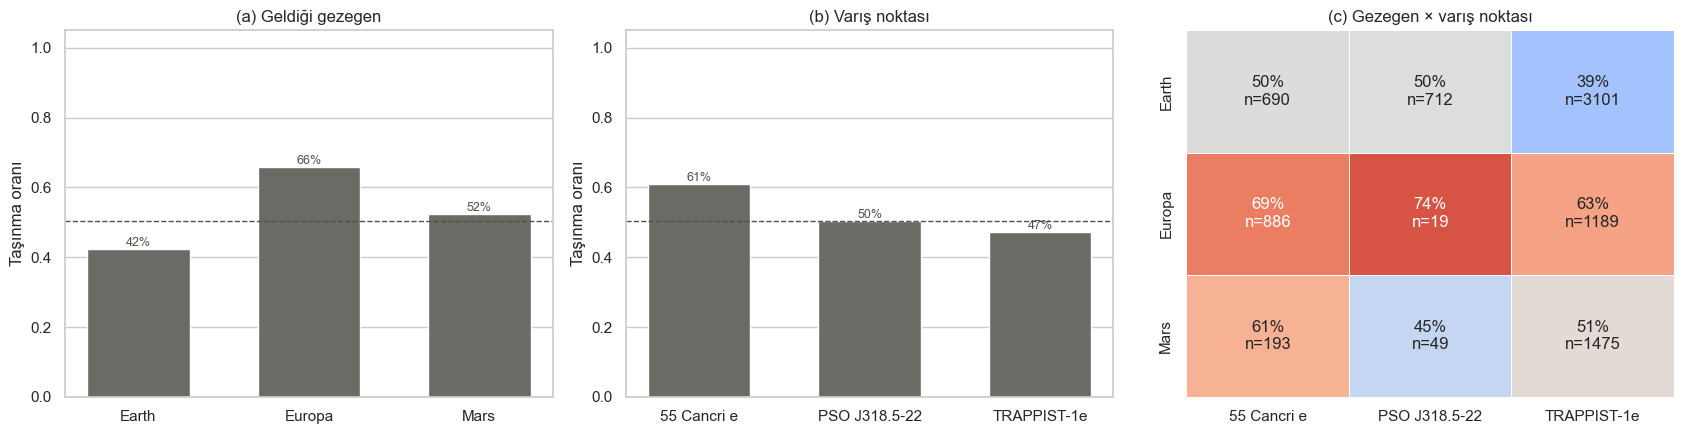

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
rate_bar(axes[0], train.groupby("HomePlanet", observed=True)["Transported"].mean(), "(a) Geldiği gezegen", "")
rate_bar(axes[1], train.groupby("Destination", observed=True)["Transported"].mean(), "(b) Varış noktası", "")

ax = axes[2]
pivot = train.pivot_table(index="HomePlanet", columns="Destination", values="Transported", aggfunc="mean", observed=True)
counts = train.pivot_table(index="HomePlanet", columns="Destination", values="Transported", aggfunc="size", observed=True)
sns.heatmap(pivot, annot=pivot.map("{:.0%}".format) + counts.map("\nn={}".format), fmt="", cmap="coolwarm",
            vmin=0.2, vmax=0.8, cbar=False, linewidths=0.5, ax=ax)
ax.grid(False)
ax.set(title="(c) Gezegen × varış noktası", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

In [34]:
# Uyku durumunu sabit tutunca gezegen farkı kalıyor mu?
by_sleep = train.pivot_table(index="HomePlanet", columns="CryoSleep", values="Transported", aggfunc="mean", observed=True)
by_sleep.columns = ["uyanık", "uykuda"]
(by_sleep * 100).round(1).assign(
    uyuyan_pct=(train.groupby("HomePlanet", observed=True)["CryoSleep"].mean() * 100).round(1),
    kişi=train["HomePlanet"].value_counts(),
)

,uyanık,uykuda,uyuyan_pct,kişi
HomePlanet,,,,
Earth,32.10,65.60,30.80,4602
Europa,40.00,98.90,43.90,2131
Mars,27.70,91.20,39.00,1759


In [35]:
# Aynı güvertede farklı gezegenden yolcular farklı mı? (D, E, F güvertelerinde gezegenler karışık)
mixed = split_columns(train).query("Deck in ['D', 'E', 'F']")
pd.concat({
    "taşınma %": mixed.pivot_table(index="Deck", columns="HomePlanet", values="Transported", aggfunc="mean", observed=True) * 100,
    "kişi": mixed.pivot_table(index="Deck", columns="HomePlanet", values="Transported", aggfunc="size", observed=True),
}, axis=1).round(1)

taşınma %                  kişi                
HomePlanet     Earth Europa  Mars    Earth Europa     Mars
Deck                                                      
D                NaN  58.60 33.30      NaN 186.00   282.00
E              37.20  54.70 26.10   395.00 128.00   330.00
F              29.20    NaN 65.00 1,614.00    NaN 1,110.00

In [36]:
# VIP: az sayıda yolcu, taşınmayla ilişkisi var mı?
train.groupby("VIP")["Transported"].agg(taşınma_oranı="mean", kişi="size")

,taşınma_oranı,kişi
VIP,,
False,0.51,8291
True,0.38,199


**Sonuç: doğrulandı. Gezegen tek başına bir ipucu, ama güverte ve uykuyla iç içe.**

- **Gezegen:** Europa'lıların %66'sı, Mars'lıların %52'si, Earth'lülerin %42'si taşındı.
- **Uyku sabit tutulunca fark büyüyor:** uyuyan Europa'lıların %99'u, Mars'lıların %91'i taşındı, Earth'lülerin ise sadece %66'sı. 2.2'de "G güvertesinde uyuyanlar az taşınmış" demiştik; G güvertesi tamamen Earth'lü. Yani bu aynı bulgunun iki yüzü.
- **Aynı güvertede de gezegen fark ediyor, ama yönü güverteye göre değişiyor:** D ve E'de Europa'lılar (%55–59) Mars'lılardan (%26–33) çok daha fazla taşınmış; F'de ise Mars'lılar (%65) Earth'lülerden (%29) fazla. Bu tür **etkileşimler** (etkinin başka bir değişkene göre değişmesi) ağaç tabanlı modellerin güçlü olduğu yer.
- **Varış noktası:** 55 Cancri e'ye gidenler %61 ile önde. Bunun bir kısmı oraya çok sayıda Europa'lının gitmesinden geliyor. En kalabalık hücre olan Earth → TRAPPIST-1e (3101 kişi) %39 ile en düşük.
- **VIP:** VIP'ler %38, diğerleri %51. Fark var ama sadece 199 VIP yolcu var; zayıf bir ipucu. Sütunu atmıyoruz, modelin karar vermesine bırakıyoruz.

### 2.5 Yaş

**Sezgi:** 1.9'da 0–12 yaş arasındaki hiçbir çocuğun harcama yapmadığını gördük. Çocuklar farklı etkilendiyse, bu yaşın kendisinden mi yoksa "harcama yapmamaktan" mı geliyor?

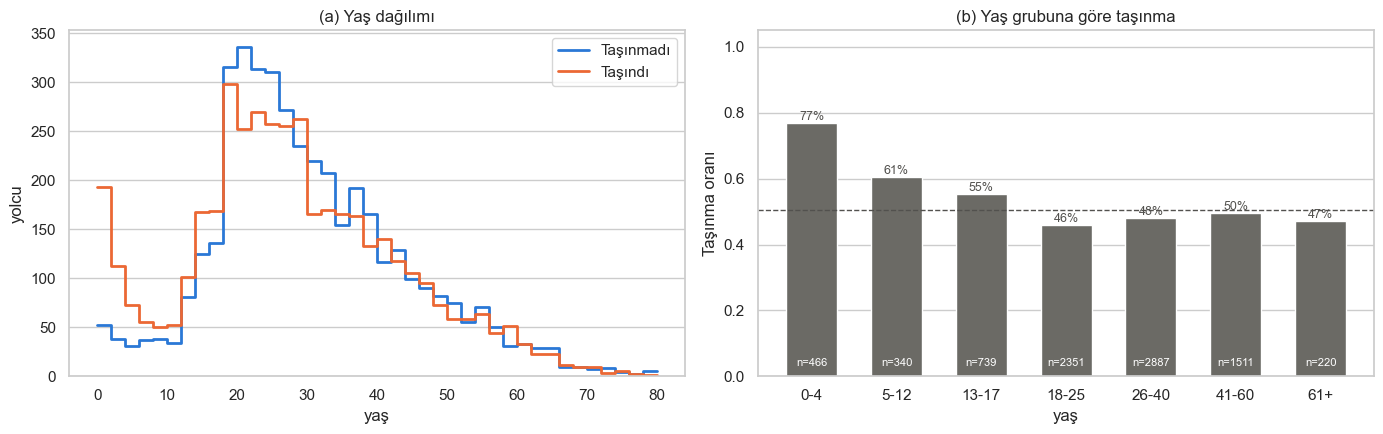

In [37]:
AGE_BINS = [-1, 4, 12, 17, 25, 40, 60, 80]
AGE_LABELS = ["0-4", "5-12", "13-17", "18-25", "26-40", "41-60", "61+"]
age_band = pd.cut(train["Age"], AGE_BINS, labels=AGE_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
for value in [False, True]:
    sns.histplot(train.loc[train["Transported"] == value, "Age"].dropna(), bins=range(0, 81, 2), element="step",
                 fill=False, linewidth=2, color=TARGET_COLORS[value], label=TARGET_LABELS[value], ax=ax)
ax.set(title="(a) Yaş dağılımı", xlabel="yaş", ylabel="yolcu")
ax.legend()

ab = train.groupby(age_band, observed=True)["Transported"].agg(["mean", "size"])
rate_bar(axes[1], ab["mean"], "(b) Yaş grubuna göre taşınma", "yaş")
for i, n in enumerate(ab["size"]):
    axes[1].annotate(f"n={n}", (i, 0.03), ha="center", fontsize=8, color="white")
plt.tight_layout()
plt.show()

In [38]:
# Aynı durumdaki yetişkinlerle karşılaştır: çocuk etkisi yaştan mı, harcamamaktan mı?
state = pd.Series(
    np.select([train["CryoSleep"].fillna(False).astype(bool), train[SPEND_COLS].sum(axis=1) == 0],
              ["uykuda", "uyanık, harcama yok"], "uyanık, harcama var"),
    index=train.index,
)
state[train["CryoSleep"].isna()] = np.nan
pd.concat({
    "taşınma %": train.pivot_table(index=age_band, columns=state, values="Transported", aggfunc="mean", observed=True) * 100,
    "kişi": train.pivot_table(index=age_band, columns=state, values="Transported", aggfunc="size", observed=True),
}, axis=1).round(1)

taşınma %                                           kişi  \
      uyanık, harcama var uyanık, harcama yok uykuda uyanık, harcama var   
Age                                                                        
0-4                   NaN               76.20  78.10                 NaN   
5-12                  NaN               59.40  62.90                 NaN   
13-17               25.60               20.00  84.80              356.00   
18-25               31.10               20.00  78.60            1,536.00   
26-40               29.00               38.80  85.50            1,832.00   
41-60               32.10               55.00  83.60              965.00   
61+                 26.60              100.00  88.70              143.00   

                                  
      uyanık, harcama yok uykuda  
Age                               
0-4                214.00 237.00  
5-12               192.00 140.00  
13-17                5.00 356.00  
18-25               30.00 721.00  
26-40               49.00 941.00  
41-60               20.00 489.00  
61+                  1.00  71.00

**Sonuç: doğrulandı, küçük çocuklar gerçekten farklı.**

- 0–4 yaş %77, 5–12 yaş %61, 13–17 yaş %55; yetişkinlerde oran %46–50 arasında sabit. Dağılım grafiğinde 0–2 yaşta taşınanlar belirgin biçimde fazla.
- **Fark sadece harcamamaktan gelmiyor.** Uyanık ve harcama yapmayan yolcular içinde: 0–4 yaş %76, 18–25 yaş %20, 26–40 yaş %39. Aynı durumdaki yetişkinlere göre küçük çocuklar çok daha fazla taşınmış.
- 2.1'deki "uyanık ama harcama yok" grubunun (%62) sırrı da bu: o 518 kişinin 406'sı 12 yaş altı çocuk.
- Uyuyanlarda ise yaş neredeyse fark etmiyor (%63–89 arası, küçük çocuklar biraz daha düşük).
- Yetişkinler arasında yaşın etkisi yok denecek kadar az. Yaşı ham sayı yerine **yaş grubu ve çocuk bayrağı** olarak kullanmak işimizi görür.

### Bölüm 2 özeti: Kim taşındı?

| Hipotez | Sonuç | Güç | Modele etkisi |
|---|---|---|---|
| Uyku ve harcama | Doğrulandı: uyuyanlar %82, harcama yapan uyanıklar %30 | Çok güçlü | Harcamaları iki gruba ayır: lüks (RoomService, Spa, VRDeck) ve temel (FoodCourt, ShoppingMall); log dönüşümü |
| Kabin konumu | Doğrulandı: B/C güverteleri, sağ taraf, sağda 600–1100 bölgesi | Güçlü | `Cabin` → `Deck`, `Side`, kabin bölgesi |
| Gezegen ve varış | Doğrulandı, güverteyle iç içe; etkileşim var | Orta | Ağaç tabanlı modeller etkileşimi yakalar |
| Yaş | Doğrulandı: 0–4 yaş %77; uyanık, harcamasız çocuklar aynı durumdaki yetişkinlerden çok daha fazla taşınmış | Orta | Yaş grubu, çocuk bayrağı |
| Grup ve aile | Kısmen: yalnızlar daha az taşınıyor, kader paylaşılmıyor | Zayıf–orta | `GroupSize`, yalnızlık; grup hedefi kullanılmaz |
| VIP | Zayıf fark, 199 kişi | Zayıf | Sütun kalıyor, karar modelde |

Taşınmayı yolcunun **ne yaptığı** (uyku, harcama) ve **nerede olduğu** (güverte, taraf, kabin bölgesi) belirliyor. Gruplar train ve test arasında bölünmediği için CV'yi de grupları ayırarak (GroupKFold) kuracağız.

## Bölüm 3: Veriyi Modele Hazırlamak

Üç adım:

1. **Sütun ayrıştırma:** birleşik sütunları parçalarına ayırmak.
2. **Kurallı doldurma:** 1.9'da veriyle doğruladığımız ilişkilerle eksikleri doldurmak. Bu kurallar hedefi (`Transported`) kullanmadığı için train ve test'e birlikte uygulanabilir.
3. **Pipeline:** kurallardan sonra kalan eksikleri istatistikle (medyan, en sık değer) doldurmak, kategorileri sayıya çevirmek. Bu istatistikler verinin tamamından değil, **her CV turunda yalnızca eğitim kısmından** öğreniliyor; böylece doğrulama verisinden bilgi sızmıyor.

### 3.1 Sütun ayrıştırma

In [39]:
full = split_columns(pd.concat([train.drop(columns="Transported"), test], keys=["train", "test"]).reset_index(level=0).rename(columns={"level_0": "set"}).reset_index(drop=True))
full["CabinNum"] = full["CabinNum"].astype(float)
full[["PassengerId", "Group", "GroupSize", "Cabin", "Deck", "CabinNum", "Side", "Name", "Surname"]].head()

,PassengerId,Group,GroupSize,Cabin,Deck,CabinNum,Side,Name,Surname
0,0001_01,0001,1,B/0/P,B,0.00,P,Maham Ofracculy,Ofracculy
1,0002_01,0002,1,F/0/S,F,0.00,S,Juanna Vines,Vines
2,0003_01,0003,2,A/0/S,A,0.00,S,Altark Susent,Susent
3,0003_02,0003,2,A/0/S,A,0.00,S,Solam Susent,Susent
4,0004_01,0004,1,F/1/S,F,1.00,S,Willy Santantines,Santantines


### 3.2 Kurallı doldurma

Kurallar sırayla uygulanıyor; bir kuralın doldurduğu değer, sonraki kurallar için ipucu olabiliyor (örneğin önce soyadı gruptan dolduruluyor, sonra gezegen soyaddan).

| # | Sütun | Kural | Dayanak |
|---|---|---|---|
| 1 | Harcamalar | CryoSleep = True → 0 | Uyuyan 4581 yolcunun hiçbiri harcama yapmamış (1.9) |
| 2 | Harcamalar | Yaş ≤ 12 → 0 | 0–12 yaş arası 1157 çocuğun hiçbiri harcama yapmamış (1.9) |
| 3 | CryoSleep | Herhangi bir harcama > 0 → False | Kural 1'in tersi |
| 4 | CryoSleep | Hiç harcama yok ve yaş > 12 → True | Harcamasız 12 yaş üstü yolcuların %96'sı uykuda; çocuklarda bu oran %48, bu yüzden onlara uygulanmıyor |
| 5 | Surname | Gruptaki en sık soyadı | Grupların %82'si aynı soyadlı (1.9) |
| 6 | HomePlanet | Grubun gezegeni | %100 tutarlı (1.9) |
| 7 | HomePlanet | Soyadının gezegeni | %100 tutarlı (1.9) |
| 8 | HomePlanet | Güverte A/B/C/T → Europa, G → Earth | %100 tutarlı (1.9) |
| 9 | Side | Grubun tarafı | %100 tutarlı (1.9) |
| 10 | Deck, CabinNum | Gruptaki en sık değer | %67 tutarlı; genel en sık değerden iyi |
| 11 | VIP | Earth → False | Earth'ten hiç VIP yok (1.9) |
| 12 | VIP | Yaş < 18 → False | 18 yaş altında hiç VIP yok |

`Destination` ve `Age` için güvenilir bir kural yok; bunlar pipeline'da dolduruluyor.

In [40]:
def mode_by(df, col, key):
    # key (örn. Group) içindeki en sık col değeri, her satıra eşlenmiş
    known = df.dropna(subset=[col, key])
    modes = known.groupby(key)[col].agg(lambda s: s.mode().iloc[0])
    return df[key].map(modes)


def apply_rules(df):
    df = df.copy()
    log = []

    def fill(col, candidate, rule):
        mask = df[col].isna() & candidate.notna()
        df.loc[mask, col] = candidate[mask]
        log.append({"sütun": col, "kural": rule, "doldurulan": int(mask.sum())})

    asleep = df["CryoSleep"].fillna(False).astype(bool)
    child = df["Age"] <= 12
    for col in SPEND_COLS:
        fill(col, pd.Series(np.where(asleep, 0.0, np.nan), index=df.index), "CryoSleep = True → 0")
    for col in SPEND_COLS:
        fill(col, pd.Series(np.where(child, 0.0, np.nan), index=df.index), "yaş ≤ 12 → 0")

    spent = df[SPEND_COLS].gt(0).any(axis=1)
    no_spend = df[SPEND_COLS].notna().all(axis=1) & (df[SPEND_COLS].sum(axis=1) == 0)
    fill("CryoSleep", pd.Series(np.where(spent, False, None), index=df.index), "harcama > 0 → False")
    fill("CryoSleep", pd.Series(np.where(no_spend & (df["Age"] > 12), True, None), index=df.index), "harcama yok, yaş > 12 → True")

    fill("Surname", mode_by(df, "Surname", "Group"), "grubun soyadı")
    fill("HomePlanet", mode_by(df, "HomePlanet", "Group"), "grubun gezegeni")
    fill("HomePlanet", mode_by(df, "HomePlanet", "Surname"), "soyadının gezegeni")
    fill("HomePlanet", df["Deck"].map({"A": "Europa", "B": "Europa", "C": "Europa", "T": "Europa", "G": "Earth"}),
         "güverte → gezegen")
    fill("Side", mode_by(df, "Side", "Group"), "grubun tarafı")
    fill("Deck", mode_by(df, "Deck", "Group"), "grubun güvertesi")
    fill("CabinNum", mode_by(df, "CabinNum", "Group"), "grubun kabin numarası")
    fill("VIP", pd.Series(np.where(df["HomePlanet"] == "Earth", False, None), index=df.index), "Earth → False")
    fill("VIP", pd.Series(np.where(df["Age"] < 18, False, None), index=df.index), "yaş < 18 → False")

    df["CryoSleep"] = df["CryoSleep"].astype("boolean")
    df["VIP"] = df["VIP"].astype("boolean")
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1, min_count=1)
    return df, pd.DataFrame(log)


CHECK_COLS = ["HomePlanet", "CryoSleep", "Destination", "Age", "VIP"] + SPEND_COLS + ["Deck", "CabinNum", "Side", "Surname"]
before = full[CHECK_COLS].isna().sum()
full_filled, rule_log = apply_rules(full)
after = full_filled[CHECK_COLS].isna().sum()

rule_log.groupby(["sütun", "kural"], sort=False)["doldurulan"].sum().to_frame()

,,doldurulan
sütun,kural,
RoomService,CryoSleep = True → 0,93
FoodCourt,CryoSleep = True → 0,109
ShoppingMall,CryoSleep = True → 0,131
Spa,CryoSleep = True → 0,107
VRDeck,CryoSleep = True → 0,91
RoomService,yaş ≤ 12 → 0,8
FoodCourt,yaş ≤ 12 → 0,9
ShoppingMall,yaş ≤ 12 → 0,12
Spa,yaş ≤ 12 → 0,11


In [41]:
pd.DataFrame({
    "önce": before,
    "kurallardan sonra": after,
    "kurallarla doldurulan %": ((before - after) / before * 100).round(1),
})

,önce,kurallardan sonra,kurallarla doldurulan %
HomePlanet,288,10,96.50
CryoSleep,310,38,87.70
Destination,274,274,0.00
Age,270,270,0.00
VIP,296,123,58.40
RoomService,263,162,38.40
FoodCourt,289,171,40.80
ShoppingMall,306,163,46.70
Spa,284,166,41.50
VRDeck,268,150,44.00


In [42]:
# Kontrol: kurallar birbiriyle çelişen bir satır bıraktı mı?
pd.Series({
    "uyuyan ama harcama yapmış": (full_filled["CryoSleep"].fillna(False).astype(bool) & (full_filled["TotalSpend"] > 0)).sum(),
    "12 yaş altı ama harcama yapmış": ((full_filled["Age"] <= 12) & (full_filled["TotalSpend"] > 0)).sum(),
    "Earth'lü VIP": ((full_filled["HomePlanet"] == "Earth") & full_filled["VIP"].fillna(False).astype(bool)).sum(),
    "G güvertesinde Earth dışı": ((full_filled["Deck"] == "G") & (full_filled["HomePlanet"].notna()) & (full_filled["HomePlanet"] != "Earth")).sum(),
})

uyuyan ama harcama yapmış         0
12 yaş altı ama harcama yapmış    0
Earth'lü VIP                      0
G güvertesinde Earth dışı         0
dtype: int64

**Kurallar ne kadar doğru?** Değeri bilinen yolcularda o değeri gizleyip kurala tahmin ettiriyoruz ve gerçek değerle karşılaştırıyoruz. Gruba ve soyada dayalı kurallarda yolcunun kendisi hesaba katılmıyor, sadece diğer üyelere bakılıyor.

In [43]:
def loo_mode(df, col, key):
    # Her yolcu için: aynı key'deki DİĞER yolcuların en sık col değeri
    known = df.dropna(subset=[col, key])
    counts = known.groupby([key, col], observed=True).size()
    out = pd.Series(np.nan, index=known.index, dtype=object)
    for idx, k, v in zip(known.index, known[key], known[col]):
        c = counts.loc[k].copy()
        c[v] -= 1
        c = c[c > 0]
        if len(c):
            out[idx] = c.idxmax()
    return out


def rule_check(name, actual, predicted):
    m = actual.notna() & predicted.notna()
    return {"kural": name, "test edilen yolcu": int(m.sum()),
            "doğruluk %": round((actual[m].astype(str) == predicted[m].astype(str)).mean() * 100, 2)}


asleep = full["CryoSleep"] == True
spend_known = full[SPEND_COLS].notna().all(axis=1)
no_spend = spend_known & (full["TotalSpend"] == 0)
checks = [
    rule_check("uyuyan → harcama 0", (full.loc[asleep & spend_known, "TotalSpend"] == 0), pd.Series(True, index=full[asleep & spend_known].index)),
    rule_check("yaş ≤ 12 → harcama 0", (full.loc[(full["Age"] <= 12) & spend_known, "TotalSpend"] == 0),
               pd.Series(True, index=full[(full["Age"] <= 12) & spend_known].index)),
    rule_check("harcama > 0 → uyanık", full.loc[full["TotalSpend"] > 0, "CryoSleep"], pd.Series(False, index=full[full["TotalSpend"] > 0].index)),
    rule_check("harcama yok, yaş > 12 → uykuda", full.loc[no_spend & (full["Age"] > 12), "CryoSleep"],
               pd.Series(True, index=full[no_spend & (full["Age"] > 12)].index)),
    rule_check("grup → soyadı", full["Surname"], loo_mode(full, "Surname", "Group")),
    rule_check("grup → gezegen", full["HomePlanet"], loo_mode(full, "HomePlanet", "Group")),
    rule_check("soyadı → gezegen", full["HomePlanet"], loo_mode(full, "HomePlanet", "Surname")),
    rule_check("güverte → gezegen", full["HomePlanet"], full["Deck"].map({"A": "Europa", "B": "Europa", "C": "Europa", "T": "Europa", "G": "Earth"})),
    rule_check("grup → taraf", full["Side"], loo_mode(full, "Side", "Group")),
    rule_check("grup → güverte", full["Deck"], loo_mode(full, "Deck", "Group")),
    rule_check("grup → kabin numarası", full["CabinNum"], loo_mode(full, "CabinNum", "Group")),
    rule_check("Earth → VIP değil", full.loc[full["HomePlanet"] == "Earth", "VIP"], pd.Series(False, index=full[full["HomePlanet"] == "Earth"].index)),
    rule_check("yaş < 18 → VIP değil", full.loc[full["Age"] < 18, "VIP"], pd.Series(False, index=full[full["Age"] < 18].index)),
]
rule_acc = pd.DataFrame(checks).set_index("kural")

# Karşılaştırma: basit doldurma (en sık değer) aynı yolcularda ne kadar doğru olurdu?
simple_acc = {
    "grup → gezegen": (full["HomePlanet"].dropna() == full["HomePlanet"].mode()[0]).mean() * 100,
    "soyadı → gezegen": (full["HomePlanet"].dropna() == full["HomePlanet"].mode()[0]).mean() * 100,
    "grup → güverte": (full["Deck"].dropna() == full["Deck"].mode()[0]).mean() * 100,
    "grup → taraf": (full["Side"].dropna() == full["Side"].mode()[0]).mean() * 100,
    "harcama yok, yaş > 12 → uykuda": (full["CryoSleep"].dropna() == full["CryoSleep"].mode()[0]).mean() * 100,
}
rule_acc["en sık değerle doldurma %"] = pd.Series(simple_acc).round(2)
rule_acc

,test edilen yolcu,doğruluk %,en sık değerle doldurma %
kural,,,
uyuyan → harcama 0,4068,100.00,NaN
yaş ≤ 12 → harcama 0,1030,100.00,NaN
harcama > 0 → uyanık,7339,100.00,NaN
"harcama yok, yaş > 12 → uykuda",3615,96.40,63.82
grup → soyadı,5622,85.82,NaN
grup → gezegen,5634,100.00,54.13
soyadı → gezegen,12183,100.00,54.13
güverte → gezegen,6261,100.00,NaN
grup → taraf,5620,100.00,50.36


### 3.3 Pipeline

Kurallardan sonra kalan eksikler ve modele verilecek dönüşümler:

| Sütun türü | Sütunlar | Eksik doldurma | Dönüşüm |
|---|---|---|---|
| Yaş | `Age` | Gezegen × harcama durumuna göre medyan (1.9) | Ölçekleme |
| Harcamalar | 5 hizmet | Medyan (0) | `log(1 + x)`, ölçekleme (çarpıklık 6–13) |
| Kabin numarası | `CabinNum` | Medyan | Ölçekleme |
| Mantıksal | `CryoSleep`, `VIP` | En sık değer | 0/1 |
| Kategorik | `HomePlanet`, `Destination`, `Deck`, `Side` | En sık değer | One-hot |

Bu adımda yalnızca orijinal bilgiyi kullanıyoruz; yeni özellikler (harcama grupları, kabin bölgesi, grup büyüklüğü) Adım 4'te eklenecek. Böylece her adımın katkısını ayrı ayrı ölçebileceğiz.

In [44]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


class AgeImputer(BaseEstimator, TransformerMixin):
    # Eksik yaşı, eğitim verisinden öğrenilen gezegen × harcama medyanıyla doldurur
    def _key(self, X):
        return X["HomePlanet"].astype(str) + "_" + (X[SPEND_COLS].sum(axis=1) > 0).astype(str)

    def fit(self, X, y=None):
        self.medians_ = X.groupby(self._key(X))["Age"].median()
        self.global_median_ = X["Age"].median()
        return self

    def transform(self, X):
        X = X.copy()
        X["Age"] = X["Age"].fillna(self._key(X).map(self.medians_)).fillna(self.global_median_)
        return X


BASE_NUM = ["Age", "CabinNum"]
BASE_BOOL = ["CryoSleep", "VIP"]
BASE_CAT = ["HomePlanet", "Destination", "Deck", "Side"]
BASE_FEATURES = BASE_NUM + SPEND_COLS + BASE_BOOL + BASE_CAT


BASE_SPEC = {"num": BASE_NUM, "log": SPEND_COLS, "bool": BASE_BOOL, "cat": BASE_CAT}


def to_model_frame(df, spec=BASE_SPEC):
    # boolean/category tiplerini sklearn'ün anladığı float/object'e çevir
    cols = list(dict.fromkeys(sum(spec.values(), []) + ["HomePlanet"] + SPEND_COLS))  # AgeImputer için
    X = df[cols].copy()
    X[spec["bool"]] = X[spec["bool"]].astype("float")
    X[spec["cat"]] = X[spec["cat"]].astype("object").where(X[spec["cat"]].notna(), np.nan)
    return X


def make_preprocessor(spec=BASE_SPEC, age_imputer=True):
    columns = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), spec["num"]),
        ("log", make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p), StandardScaler()), spec["log"]),
        ("bool", SimpleImputer(strategy="most_frequent"), spec["bool"]),
        ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), spec["cat"]),
    ])
    steps = [("age", AgeImputer())] if age_imputer else []
    return Pipeline(steps + [("columns", columns)])


is_train = full_filled["set"] == "train"
y = train["Transported"].astype(int).values
groups = full_filled.loc[is_train, "Group"].values
X_rules = to_model_frame(full_filled[is_train])
X_simple = to_model_frame(full[is_train])  # sadece ayrıştırma, kural yok

prep = make_preprocessor().fit(X_rules)
Xt = prep.transform(X_rules)
print(f"Pipeline çıktısı: {Xt.shape[0]} satır × {Xt.shape[1]} sütun, kalan eksik: {np.isnan(Xt).sum()}")

Pipeline çıktısı: 8693 satır × 25 sütun, kalan eksik: 0


### 3.4 Pipeline çalışıyor mu? İlk ölçüm

Pipeline'ı iki modelle deniyoruz: doğrusal bir model (Logistic Regression) ve ağaç tabanlı bir model (HistGradientBoosting, varsayılan ayarlar). İki soru soruyoruz:

- **Kurallı doldurma işe yarıyor mu?** Aynı pipeline'ı kurallar olmadan (sadece medyan / en sık değer) da çalıştırıyoruz.
- **CV nasıl kurulmalı?** 2.3'te gruplar train ve test arasında hiç bölünmemişti. Normal KFold ile grupları ayıran StratifiedGroupKFold'u karşılaştırıyoruz.

Her ölçüm 5 katlı CV × 3 tekrar = 15 skor.

In [45]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
}


def cv_scores(model, X, cv_kind="group", repeats=3):
    scores = []
    for seed in range(repeats):
        if cv_kind == "group":
            cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
            scores += list(cross_val_score(model, X, y, cv=cv, groups=groups, scoring="accuracy"))
        else:
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
            scores += list(cross_val_score(model, X, y, cv=cv, scoring="accuracy"))
    return np.array(scores)


results = {}
for name, model in MODELS.items():
    for label, X in [("kuralsız", X_simple), ("kurallı", X_rules)]:
        s = cv_scores(Pipeline([("prep", make_preprocessor()), ("model", model)]), X)
        results[(name, label)] = s

pd.DataFrame(
    {k: {"ortalama %": v.mean() * 100, "std %": v.std() * 100} for k, v in results.items()}
).T.round(2)

ortalama %  std %
Logistic Regression  kuralsız       77.82   0.94
                     kurallı        77.81   0.84
HistGradientBoosting kuralsız       80.85   0.63
                     kurallı        80.75   0.81

In [46]:
# CV türü: gruplar bölünürse skor değişiyor mu?
hgb = Pipeline([("prep", make_preprocessor()), ("model", HistGradientBoostingClassifier(random_state=0))])
cv_compare = {kind: cv_scores(hgb, X_rules, cv_kind=kind) for kind in ["plain", "group"]}
pd.DataFrame({
    "StratifiedKFold (gruplar bölünebilir)": [cv_compare["plain"].mean() * 100, cv_compare["plain"].std() * 100],
    "StratifiedGroupKFold (gruplar bir arada)": [cv_compare["group"].mean() * 100, cv_compare["group"].std() * 100],
}, index=["ortalama %", "std %"]).T.round(2)

,ortalama %,std %
StratifiedKFold (gruplar bölünebilir),80.83,0.55
StratifiedGroupKFold (gruplar bir arada),80.75,0.81


**Accuracy dışındaki ölçüler.** Yarışma accuracy ile puanlıyor, ama modelin hangi yönde hata yaptığını görmek için diğer ölçülere de bakıyoruz:

- **Precision:** "taşındı" dediklerimizin ne kadarı gerçekten taşınmış?
- **Recall:** gerçekten taşınanların ne kadarını yakaladık?
- **F1:** precision ile recall'un dengesi.
- **ROC AUC:** model yolcuları taşınma olasılığına göre ne kadar iyi sıralıyor? 0.5 rastgele tahmin, 1.0 kusursuz sıralama demek.

In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_validate, cross_val_predict

SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_rows = {}
for name, model in MODELS.items():
    for label, X in [("kuralsız", X_simple), ("kurallı", X_rules)]:
        pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])
        per_seed = [cross_validate(pipe, X, y, groups=groups, scoring=SCORING,
                                   cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed))
                    for seed in range(3)]
        metric_rows[(name, label)] = {
            m: f"{np.mean(np.concatenate([r[f'test_{m}'] for r in per_seed])):.4f} ± {np.std(np.concatenate([r[f'test_{m}'] for r in per_seed])):.4f}"
            for m in SCORING
        }
pd.DataFrame(metric_rows).T

accuracy        precision  \
Logistic Regression  kuralsız  0.7782 ± 0.0094  0.7720 ± 0.0137   
                     kurallı   0.7781 ± 0.0084  0.7721 ± 0.0133   
HistGradientBoosting kuralsız  0.8085 ± 0.0063  0.8095 ± 0.0124   
                     kurallı   0.8075 ± 0.0081  0.8083 ± 0.0142   

                                        recall               f1  \
Logistic Regression  kuralsız  0.7943 ± 0.0115  0.7829 ± 0.0091   
                     kurallı   0.7935 ± 0.0117  0.7826 ± 0.0084   
HistGradientBoosting kuralsız  0.8104 ± 0.0113  0.8098 ± 0.0082   
                     kurallı   0.8096 ± 0.0121  0.8089 ± 0.0102   

                                       roc_auc  
Logistic Regression  kuralsız  0.8521 ± 0.0069  
                     kurallı   0.8530 ± 0.0067  
HistGradientBoosting kuralsız  0.9003 ± 0.0064  
                     kurallı   0.9022 ± 0.0054

In [48]:
# Karışıklık matrisi: HistGradientBoosting, kurallı, her yolcu bir kez doğrulamada
pred = cross_val_predict(Pipeline([("prep", make_preprocessor()), ("model", HistGradientBoostingClassifier(random_state=0))]),
                         X_rules, y, groups=groups, cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0))
cm = pd.DataFrame(confusion_matrix(y, pred), index=["gerçek: taşınmadı", "gerçek: taşındı"],
                  columns=["tahmin: taşınmadı", "tahmin: taşındı"])
cm

,tahmin: taşınmadı,tahmin: taşındı
gerçek: taşınmadı,3480,835
gerçek: taşındı,856,3522


**Sonuç**

- **Pipeline çalışıyor:** 8693 satır × 25 sütun, eksik değer kalmadı. Kurallar birbiriyle çelişen hiçbir satır bırakmadı.
- **Kurallar eksiklerin büyük kısmını doldurdu:** HomePlanet'teki eksiklerin %97'si, CryoSleep'tekilerin %88'i kurallarla doldu. Harcama, kabin ve soyadı sütunlarında bu oran %40–47.
- **Ama CV skoru değişmedi:** kurallı ve kuralsız fark 0.1 puanın altında, yani skorların standart sapmasının (0.6–0.9) çok içinde. Bunun iki nedeni var:
  - Her sütunda eksik oranı sadece %2. Kurallar train'de her sütun için yalnızca 100–200 hücreyi değiştiriyor, bu da tahminlerin ancak küçük bir kısmına dokunuyor.
  - Harcamalarda medyan zaten 0. Yani "uyuyanın harcaması 0" kuralı çoğu satırda medyanla aynı sonucu veriyor.
- **Ağaç tabanlı model doğrusal modelden 3 puan önde** (%80.8'e karşı %77.8). 2.4'te gördüğümüz etkileşimler bunu destekliyor.
- **CV türü de fark etmedi** (%80.83'e karşı %80.75). Grupların bölünmesi şimdilik skoru şişirmiyor. Adım 4'te gruba dayalı özellikler eklediğimizde sızıntı riski artacağı için grupları bir arada tutan StratifiedGroupKFold ile devam ediyoruz.

## Bölüm 4: Bulgulardan Özelliklere

Bölüm 2'deki her bulguyu modelin kullanabileceği bir sütuna çeviriyoruz:

| Özellik seti | Yeni sütunlar | Dayandığı bulgu |
|---|---|---|
| Harcama grupları | `LuxurySpend` (RoomService + Spa + VRDeck), `BasicSpend` (FoodCourt + ShoppingMall), `TotalSpend`, `NoSpend` | 2.1: lüks harcama arttıkça taşınma düşüyor, temel harcamada U biçimi |
| Kabin bölgesi | `CabinRegion` (kabin numarası 300'lük bloklar) | 2.2: sağ tarafta 600–1100 bölgesi |
| Grup | `GroupSize`, `IsSolo` | 2.3: yalnızlar %45, gruptakiler %57 |
| Aile | `FamilySize` (aynı soyadlı kişi sayısı) | 2.3: kalabalık ailelerde oran düşük |
| Yaş | `IsChild` (≤ 12), `AgeGroup` | 2.5: 0–4 yaş %77 |

Grup ve aile büyüklükleri hedefi kullanmadan train + test birlikte sayılıyor.

In [49]:
def add_features(df):
    df = df.copy()
    df["LuxurySpend"] = df[["RoomService", "Spa", "VRDeck"]].sum(axis=1)
    df["BasicSpend"] = df[["FoodCourt", "ShoppingMall"]].sum(axis=1)
    df["TotalSpend"] = df[SPEND_COLS].sum(axis=1)
    df["NoSpend"] = (df["TotalSpend"] == 0).astype(float)
    df["CabinRegion"] = (df["CabinNum"] // 300).astype("Int64").astype(str).replace("<NA>", np.nan)
    df["IsSolo"] = (df["GroupSize"] == 1).astype(float)
    df["FamilySize"] = df["Surname"].map(df["Surname"].value_counts())
    df["IsChild"] = (df["Age"] <= 12).astype(float).where(df["Age"].notna())
    df["AgeGroup"] = pd.cut(df["Age"], AGE_BINS, labels=AGE_LABELS).astype(object)
    # 7.4'te bulunan bölge: alt güverteler (F, G), sağ taraf, 600–1199 numaralı kabinler
    df["HotZone"] = (df["Deck"].isin(["F", "G"]) & (df["Side"] == "S") & df["CabinNum"].between(600, 1199)).astype(float)
    df.loc[df["CabinNum"].isna() | df["Side"].isna() | df["Deck"].isna(), "HotZone"] = np.nan
    return df


fe = add_features(full_filled)
X_fe_all = fe[is_train]

FEATURE_SETS = {
    "harcama grupları": {"log": ["LuxurySpend", "BasicSpend", "TotalSpend"], "bool": ["NoSpend"]},
    "kabin bölgesi": {"cat": ["CabinRegion"]},
    "grup": {"num": ["GroupSize"], "bool": ["IsSolo"]},
    "aile": {"num": ["FamilySize"]},
    "yaş": {"bool": ["IsChild"], "cat": ["AgeGroup"]},
}


def extend(spec, *extras):
    out = {k: list(v) for k, v in spec.items()}
    for extra in extras:
        for k, v in extra.items():
            out[k] = out[k] + v
    return out


fe[is_train][["LuxurySpend", "BasicSpend", "TotalSpend", "NoSpend", "CabinRegion", "GroupSize", "IsSolo",
              "FamilySize", "IsChild", "AgeGroup"]].head()

,LuxurySpend,BasicSpend,TotalSpend,NoSpend,CabinRegion,GroupSize,IsSolo,FamilySize,IsChild,AgeGroup
0,0.00,0.00,0.00,1.00,0,1,1.00,4.00,0.00,26-40
1,702.00,34.00,736.00,0.00,0,1,1.00,4.00,0.00,18-25
2,"6,807.00","3,576.00","10,383.00",0.00,0,2,0.00,7.00,0.00,41-60
3,"3,522.00","1,654.00","5,176.00",0.00,0,2,0.00,7.00,0.00,26-40
4,870.00,221.00,"1,091.00",0.00,0,1,1.00,9.00,0.00,13-17


### 4.1 Her özellik seti ne katıyor?

Her seti **tek başına** temel modele ekliyoruz, sonra **hepsini birlikte** deniyoruz. Tüm deneyler aynı 15 CV bölmesini kullanıyor; böylece farklar eşleştirilmiş olarak karşılaştırılabiliyor.

Farkın gerçek mi gürültü mü olduğunu **düzeltilmiş eşleştirilmiş t-testi** (Nadeau ve Bengio, 2003) ile kontrol ediyoruz. CV bölmeleri birbiriyle örtüştüğü için sıradan t-testi farkları olduğundan daha anlamlı gösterir; bu test o örtüşmeyi hesaba katıyor. p < 0.05 ise fark büyük olasılıkla gerçek.

In [50]:
from scipy import stats

N_SPLITS, N_REPEATS = 5, 3
SPLITS = [split for seed in range(N_REPEATS)
          for split in StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed).split(X_fe_all, y, groups)]


def evaluate(model, spec):
    X = to_model_frame(X_fe_all, spec)
    pipe = Pipeline([("prep", make_preprocessor(spec)), ("model", model)])
    r = cross_validate(pipe, X, y, cv=SPLITS, scoring=["accuracy", "f1", "roc_auc"])
    return {m: r[f"test_{m}"] for m in ["accuracy", "f1", "roc_auc"]}


def corrected_ttest(a, b):
    # Nadeau & Bengio düzeltmesi: test / eğitim oranı kadar varyans ekle
    d = b - a
    ratio = 1 / (N_SPLITS - 1)
    t = d.mean() / np.sqrt((1 / len(d) + ratio) * d.var(ddof=1))
    return 2 * stats.t.sf(abs(t), df=len(d) - 1)


def run_ablation(model):
    runs = {"temel": evaluate(model, BASE_SPEC)}
    for name, extra in FEATURE_SETS.items():
        runs[f"+ {name}"] = evaluate(model, extend(BASE_SPEC, extra))
    runs["+ hepsi"] = evaluate(model, extend(BASE_SPEC, *FEATURE_SETS.values()))
    base = runs["temel"]["accuracy"]
    return pd.DataFrame({
        name: {
            "accuracy %": r["accuracy"].mean() * 100,
            "± std": r["accuracy"].std() * 100,
            "F1 %": r["f1"].mean() * 100,
            "ROC AUC %": r["roc_auc"].mean() * 100,
            "fark (puan)": (r["accuracy"].mean() - base.mean()) * 100,
            "p": np.nan if name == "temel" else corrected_ttest(base, r["accuracy"]),
        }
        for name, r in runs.items()
    }).T.round({"accuracy %": 2, "± std": 2, "F1 %": 2, "ROC AUC %": 2, "fark (puan)": 2, "p": 3}), runs


hgb_table, hgb_runs = run_ablation(HistGradientBoostingClassifier(random_state=0))
hgb_table

,accuracy %,± std,F1 %,ROC AUC %,fark (puan),p
temel,80.75,0.81,80.89,90.22,0.00,NaN
+ harcama grupları,81.26,0.81,81.41,90.49,0.51,0.07
+ kabin bölgesi,80.87,0.64,80.99,90.14,0.12,0.68
+ grup,81.03,0.77,81.16,90.17,0.28,0.33
+ aile,80.99,0.76,81.11,90.16,0.24,0.43
+ yaş,81.11,0.81,81.21,90.26,0.36,0.22
+ hepsi,81.14,0.64,81.25,90.51,0.39,0.21


In [51]:
lr_table, lr_runs = run_ablation(LogisticRegression(max_iter=3000))
lr_table

,accuracy %,± std,F1 %,ROC AUC %,fark (puan),p
temel,77.81,0.84,78.26,85.30,0.00,NaN
+ harcama grupları,79.61,0.83,80.04,86.17,1.80,0.00
+ kabin bölgesi,77.86,0.80,78.32,85.83,0.05,0.86
+ grup,77.73,0.89,78.19,85.31,-0.08,0.53
+ aile,77.80,0.84,78.26,85.29,-0.00,0.90
+ yaş,77.78,0.84,78.22,85.39,-0.02,0.88
+ hepsi,79.89,0.91,80.29,86.87,2.08,0.00


**Sonuç**

- **HistGradientBoosting'de her özellik seti skoru biraz artırıyor, ama hiçbiri istatistiksel olarak anlamlı değil.** En büyük kazanç harcama gruplarından geliyor: +0.51 puan, p = 0.07, anlamlılık sınırında. Diğerlerinin katkısı +0.1 ile +0.4 puan arasında ve gürültüden ayırt edilemiyor.
- **Hepsini birlikte eklemek, sadece harcama gruplarını eklemekten daha iyi değil** (81.14'e karşı 81.26). Ağaç modeli bu bilgilerin çoğunu ham sütunlardan zaten kendisi çıkarabiliyor: `CabinNum`'u kendi eşiklerle bölüyor, çocukları yaştan ve harcamasızlıktan tanıyor.
- **Logistic Regression'da tablo farklı:** harcama grupları +1.8 puan kazandırıyor ve fark açıkça anlamlı (p < 0.001). Doğrusal model "lüks harcama taşınmayı düşürür" ilişkisini tek tek hizmetlerden kendisi kuramıyor; ona hazır vermek gerekiyor. Diğer setler doğrusal modele de katkı sağlamıyor.
- **Kabin bölgesi iki modelde de işe yaramadı.** 2.2'deki tepe sadece sağ tarafta vardı; bölgeyi taraftan bağımsız eklemek bu etkileşimi vermiyor.
- **Bu adımın dersi:** keşifsel analizdeki güçlü bir bulgu, modele her zaman yeni bilgi olarak geçmiyor. Model aynı bilgiyi ham sütunlardan zaten öğrenmiş olabilir. Bir özelliğin katkısını her seferinde ölçmek bu yüzden gerekli.

### 4.2 İlk submission

Şu anki en iyi model (HistGradientBoosting + harcama grupları) tüm train verisiyle eğitiliyor ve test yolcuları için tahmin yapıyor. Amaç, CV skorunun Kaggle leaderboard'uyla ne kadar uyuştuğunu erkenden görmek.

In [52]:
SUBMISSION_DIR = Path("submissions")
SUBMISSION_DIR.mkdir(exist_ok=True)
X_fe_test = fe[~is_train]


def make_submission(models, spec, filename):
    # Tek model ya da model listesi (listede olasılıkların ortalaması alınır)
    models = models if isinstance(models, list) else [models]
    proba = np.mean([
        Pipeline([("prep", make_preprocessor(spec)), ("model", m)])
        .fit(to_model_frame(X_fe_all, spec), y)
        .predict_proba(to_model_frame(X_fe_test, spec))[:, 1]
        for m in models
    ], axis=0)
    pred = proba >= 0.5
    submission = pd.DataFrame({"PassengerId": X_fe_test["PassengerId"].values, "Transported": pred})
    path = SUBMISSION_DIR / filename
    submission.to_csv(path, index=False)

    # Kaggle'ın beklediği biçimle karşılaştır
    sample = pd.read_csv(DATA_DIR / "sample_submission.csv")
    saved = pd.read_csv(path)
    checks = pd.Series({
        "satır sayısı (beklenen 4277)": len(saved),
        "sütunlar sample ile aynı": list(saved.columns) == list(sample.columns),
        "PassengerId sırası sample ile aynı": saved["PassengerId"].equals(sample["PassengerId"]),
        "değerler True/False": set(saved["Transported"].unique()) <= {True, False},
        "eksik değer": int(saved.isna().sum().sum()),
        "taşındı tahmini %": round(saved["Transported"].mean() * 100, 1),
    }, dtype=object)
    return path, checks


SPEC_SPEND = extend(BASE_SPEC, FEATURE_SETS["harcama grupları"])
path, checks = make_submission(HistGradientBoostingClassifier(random_state=0), SPEC_SPEND, "01_hgb_spend_groups.csv")
print(path)
checks

submissions/01_hgb_spend_groups.csv


satır sayısı (beklenen 4277)          4277
sütunlar sample ile aynı              True
PassengerId sırası sample ile aynı    True
değerler True/False                   True
eksik değer                              0
taşındı tahmini %                    51.90
dtype: object

**Kaggle public skoru: 0.80219** (CV: 0.8126 ± 0.0081).

Fark yaklaşık 1 puan. Public leaderboard test verisinin yalnızca bir kısmıyla (yaklaşık 2100 yolcu) hesaplanıyor; bu büyüklükte bir örneklemde accuracy'nin kendi belirsizliği yaklaşık ±0.9 puan. Yani fark gürültü sınırında: CV hafif iyimser olabilir, ama leaderboard ile tutarlı. Bundan sonraki kararları CV'ye göre vermeye devam ediyoruz.

## Bölüm 5: Modeller Yarışıyor

Altı model, aynı özellikler (temel sütunlar + tüm yeni özellikler) ve aynı 15 CV bölmesiyle karşılaştırılıyor. Hepsi varsayılan ya da varsayılana yakın ayarlarda; ayar yapmak (tuning) Adım 6'nın işi.

| Model | Türü |
|---|---|
| Logistic Regression | Doğrusal |
| Random Forest | Ağaç topluluğu (bagging) |
| HistGradientBoosting | Gradient boosting (scikit-learn) |
| XGBoost | Gradient boosting |
| LightGBM | Gradient boosting |
| CatBoost | Gradient boosting |

In [53]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SPEC_ALL = extend(BASE_SPEC, *FEATURE_SETS.values())
CANDIDATES = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, n_jobs=-1, random_state=0),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=0),
    "CatBoost": CatBoostClassifier(iterations=1000, verbose=0, random_seed=0, thread_count=-1),
}

model_runs = {name: evaluate(model, SPEC_ALL) for name, model in CANDIDATES.items()}
best_name = max(model_runs, key=lambda n: model_runs[n]["accuracy"].mean())
best_acc = model_runs[best_name]["accuracy"]

model_table = pd.DataFrame({
    name: {
        "accuracy %": r["accuracy"].mean() * 100,
        "± std": r["accuracy"].std() * 100,
        "F1 %": r["f1"].mean() * 100,
        "ROC AUC %": r["roc_auc"].mean() * 100,
        f"{best_name} ile fark": (r["accuracy"].mean() - best_acc.mean()) * 100,
        "p": np.nan if name == best_name else corrected_ttest(r["accuracy"], best_acc),
    }
    for name, r in model_runs.items()
}).T.sort_values("accuracy %", ascending=False).round(3)
model_table

,accuracy %,± std,F1 %,ROC AUC %,CatBoost ile fark,p
CatBoost,81.53,0.90,81.77,90.84,0.00,NaN
LightGBM,81.23,0.69,81.20,90.47,-0.30,0.33
HistGradientBoosting,81.14,0.64,81.25,90.51,-0.38,0.26
XGBoost,81.07,0.52,81.21,90.50,-0.45,0.17
Random Forest,80.69,0.62,80.63,89.90,-0.83,0.09
Logistic Regression,79.89,0.91,80.29,86.86,-1.64,0.00


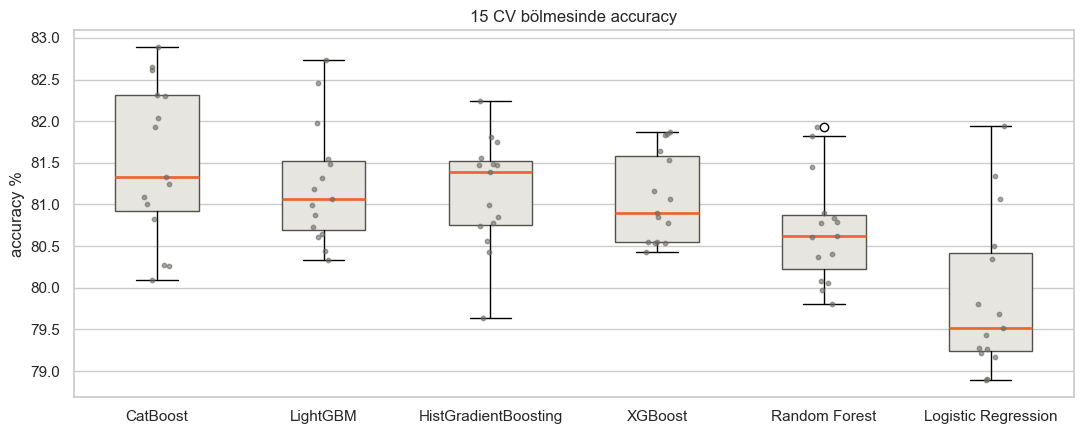

In [54]:
fig, ax = plt.subplots(figsize=(11, 4.5))
order = model_table.index.tolist()
ax.boxplot([model_runs[n]["accuracy"] * 100 for n in order], tick_labels=order, vert=True, patch_artist=True,
           boxprops={"facecolor": "#e6e5e0", "color": INK}, medianprops={"color": "#eb6834", "linewidth": 2})
for i, n in enumerate(order, start=1):
    ax.scatter(np.full(15, i) + np.random.default_rng(i).uniform(-0.08, 0.08, 15), model_runs[n]["accuracy"] * 100,
               s=10, color=NEUTRAL, alpha=0.6, zorder=3)
ax.set(title="15 CV bölmesinde accuracy", ylabel="accuracy %")
plt.tight_layout()
plt.show()

In [55]:
# Modeller birbirleriyle ne kadar aynı fikirde? Tahminlerin çakışma oranı (tek CV turu)
oof = {}
for name, model in CANDIDATES.items():
    pipe = Pipeline([("prep", make_preprocessor(SPEC_ALL)), ("model", model)])
    oof[name] = cross_val_predict(pipe, to_model_frame(X_fe_all, SPEC_ALL), y, cv=SPLITS[:N_SPLITS])
oof = pd.DataFrame(oof)
agreement = pd.DataFrame({a: {b: (oof[a] == oof[b]).mean() * 100 for b in oof} for a in oof}).round(1)
agreement

,Logistic Regression,Random Forest,HistGradientBoosting,XGBoost,LightGBM,CatBoost
Logistic Regression,100.00,89.60,89.20,89.20,88.20,89.80
Random Forest,89.60,100.00,92.80,93.20,92.80,93.70
HistGradientBoosting,89.20,92.80,100.00,94.90,95.20,94.40
XGBoost,89.20,93.20,94.90,100.00,94.50,95.00
LightGBM,88.20,92.80,95.20,94.50,100.00,94.20
CatBoost,89.80,93.70,94.40,95.00,94.20,100.00


**Sonuç**

- **Dört gradient boosting modeli başa baş.** CatBoost %81.53 ile önde, LightGBM, HistGB ve XGBoost onu 0.3–0.45 puan geriden izliyor. Ama farkların hiçbiri anlamlı değil (p = 0.17–0.33). Grafikte de kutular büyük ölçüde üst üste biniyor.
- **Random Forest biraz geride** (−0.83 puan, p = 0.09). **Logistic Regression açıkça geride** (−1.64 puan, p < 0.001); doğrusal bir model buradaki etkileşimleri yakalayamıyor.
- **CatBoost en oynak olanı** (± 0.90). En iyi bölmede %82.9, en kötüsünde %80.1.
- **Modeller %94–95 oranında aynı tahmini veriyor.** Yani farklı yolcularda yanılıyorlar; bu da bir ensemble'ın (tahminleri birleştirmenin) biraz kazanç getirebileceğini gösteriyor. Logistic Regression diğerlerinden en farklı düşünen model (%88–90 çakışma).
- Bu adımda tek bir kazanan yok. Tuning ve ensemble için dört boosting modeli birlikte ilerliyor.

## Bölüm 6: Ayar ve Birleştirme

### 6.1 Tuning (Optuna)

Dört gradient boosting modelinin ayarlarını Optuna ile arıyoruz. Optuna her denemede bir ayar seti seçiyor, CV ile ölçüyor ve önceki denemelerden öğrenerek bir sonraki seti daha akıllıca seçiyor (TPE yöntemi).

**Aşırı uyuma karşı önlem:** çok sayıda ayar denendiğinde, sırf şans eseri iyi görünen bir ayar seti bulunabilir. Bunu önlemek için:

- ayar araması **ayrı bir CV bölmesinde** (seed 42, 5 kat) yapılıyor;
- bulunan ayarlar Bölüm 5'teki **15 bölmede** raporlanıyor, varsayılan ayarlarla eşleştirilmiş olarak karşılaştırılıyor.

İki bölme de aynı veriden geldiği için bu tam bir nested CV değil; raporlanan kazanç hafif iyimser olabilir. Leaderboard bunu kontrol edecek.

Arama uzun sürüyor (model başına ~10 dakika). Sonuçlar `tuning/` klasörüne kaydediliyor ve notebook sonraki çalıştırmalarda bunları okuyor.

In [56]:
import json
import time

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
TUNING_DIR = Path("tuning")
TUNING_DIR.mkdir(exist_ok=True)
PARAMS_PATH = TUNING_DIR / "best_params.json"
TUNE_SPLITS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_fe_all, y, groups))
X_all_frame = to_model_frame(X_fe_all, SPEC_ALL)


def search_space(name, trial):
    if name == "LightGBM":
        return LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            num_leaves=trial.suggest_int("num_leaves", 8, 128, log=True),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 100, log=True),
            subsample=trial.suggest_float("subsample", 0.5, 1.0), subsample_freq=1,
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
            verbose=-1, random_state=0,
        )
    if name == "XGBoost":
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            min_child_weight=trial.suggest_float("min_child_weight", 1, 20, log=True),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
            gamma=trial.suggest_float("gamma", 0, 5),
            n_jobs=-1, random_state=0,
        )
    if name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(
            max_iter=trial.suggest_int("max_iter", 100, 1000, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 8, 64, log=True),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 100, log=True),
            l2_regularization=trial.suggest_float("l2_regularization", 1e-3, 10, log=True),
            max_features=trial.suggest_float("max_features", 0.3, 1.0),
            random_state=0,
        )
    if name == "CatBoost":
        return CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 300, 1500, step=100),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            depth=trial.suggest_int("depth", 3, 8),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 20, log=True),
            random_strength=trial.suggest_float("random_strength", 0, 5),
            bagging_temperature=trial.suggest_float("bagging_temperature", 0, 1),
            verbose=0, random_seed=0, thread_count=-1,
        )


def build_model(name, params):
    return search_space(name, optuna.trial.FixedTrial(params))


TUNED_NAMES = ["CatBoost", "LightGBM", "XGBoost", "HistGradientBoosting"]
DEFAULT_PARAMS = {  # Bölüm 5'teki ayarlar (arama aralığına yuvarlanmış)
    "LightGBM": {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 20,
                 "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 0.001},
    "XGBoost": {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 5, "min_child_weight": 1,
                "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0, "gamma": 0.0},
    "HistGradientBoosting": {"max_iter": 100, "learning_rate": 0.1, "max_leaf_nodes": 31, "min_samples_leaf": 20,
                             "l2_regularization": 0.001, "max_features": 1.0},
    "CatBoost": {"iterations": 1000, "learning_rate": 0.03, "depth": 6, "l2_leaf_reg": 3,
                 "random_strength": 1.0, "bagging_temperature": 1.0},
}
# Aşağıdaki ayarlar Optuna aramasının sonucudur (Kaggle'da aramayı beklemeden çalışabilmek için gömülü).
# Aramayı baştan çalıştırmak için RUN_SEARCH = True yap (yaklaşık 45 dakika).
SAVED_TUNING = {
    "CatBoost": {
        "params": {
            "iterations": 1500,
            "learning_rate": 0.01728104370203627,
            "depth": 6,
            "l2_leaf_reg": 9.90038502209085,
            "random_strength": 0.6985420429128288,
            "bagging_temperature": 0.21641205996520624
        },
        "tune_cv": 0.8178236788247858,
        "trials": 50,
        "minutes": 15.1
    },
    "LightGBM": {
        "params": {
            "n_estimators": 650,
            "learning_rate": 0.03920810553451383,
            "num_leaves": 9,
            "min_child_samples": 15,
            "subsample": 0.9052471815672409,
            "colsample_bytree": 0.6977646088109104,
            "reg_lambda": 0.006190178538792594
        },
        "tune_cv": 0.8137139894834439,
        "trials": 53,
        "minutes": 11.7
    },
    "XGBoost": {
        "params": {
            "n_estimators": 450,
            "learning_rate": 0.02309283878935133,
            "max_depth": 5,
            "min_child_weight": 3.1119748295109364,
            "subsample": 0.9925953601417935,
            "colsample_bytree": 0.6029960075584144,
            "reg_lambda": 0.01860095193479299,
            "gamma": 2.0912920270704465
        },
        "tune_cv": 0.8154682783355813,
        "trials": 200,
        "minutes": 9.6
    },
    "HistGradientBoosting": {
        "params": {
            "max_iter": 350,
            "learning_rate": 0.017314530172608075,
            "max_leaf_nodes": 27,
            "min_samples_leaf": 9,
            "l2_regularization": 0.10834765339309348,
            "max_features": 0.3447070334200856
        },
        "tune_cv": 0.8159808702277556,
        "trials": 28,
        "minutes": 10.2
    }
}
TIME_BUDGET = {"CatBoost": 900, "LightGBM": 600, "XGBoost": 600, "HistGradientBoosting": 600}

RUN_SEARCH = False

if RUN_SEARCH or (not PARAMS_PATH.exists() and not SAVED_TUNING):
    tuning = {}
    for name in TUNED_NAMES:
        def objective(trial):
            pipe = Pipeline([("prep", make_preprocessor(SPEC_ALL)), ("model", search_space(name, trial))])
            return cross_val_score(pipe, X_all_frame, y, cv=TUNE_SPLITS, scoring="accuracy").mean()

        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))
        study.enqueue_trial(DEFAULT_PARAMS[name])  # ilk deneme Bölüm 5'teki ayar: arama bundan geriye gidemez
        start = time.time()
        study.optimize(objective, n_trials=200, timeout=TIME_BUDGET[name])
        study.trials_dataframe().to_csv(TUNING_DIR / f"trials_{name}.csv", index=False)
        tuning[name] = {"params": study.best_params, "tune_cv": study.best_value,
                        "trials": len(study.trials), "minutes": round((time.time() - start) / 60, 1)}
    PARAMS_PATH.write_text(json.dumps(tuning, indent=2))
elif PARAMS_PATH.exists():
    tuning = json.loads(PARAMS_PATH.read_text())
else:
    tuning = SAVED_TUNING
    print("Kayıtlı ayarlar kullanılıyor (arama çalıştırılmadı).")

pd.DataFrame({n: {"deneme sayısı": t["trials"], "süre (dk)": t["minutes"], "arama CV'si %": t["tune_cv"] * 100}
              for n, t in tuning.items()}).T.round(2)

,deneme sayısı,süre (dk),arama CV'si %
CatBoost,50.00,15.10,81.78
LightGBM,53.00,11.70,81.37
XGBoost,200.00,9.60,81.55
HistGradientBoosting,28.00,10.20,81.60


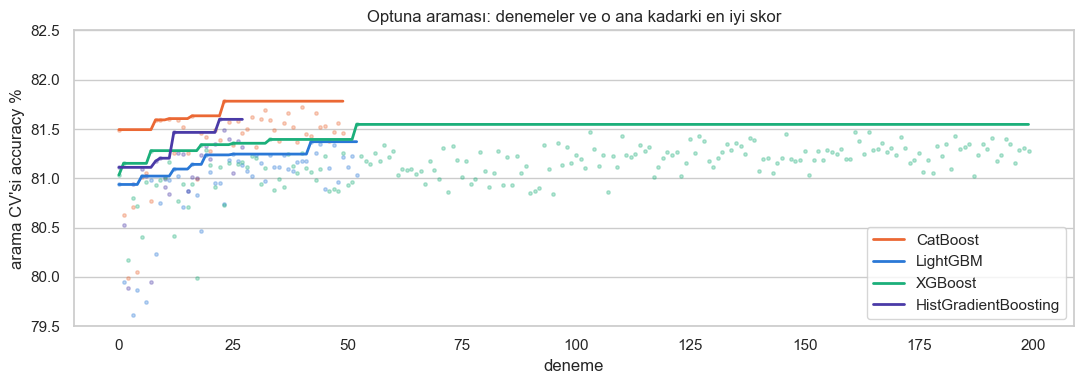

In [57]:
# Arama ilerledikçe en iyi skor nasıl değişti?
fig, ax = plt.subplots(figsize=(11, 4))
palette = {"CatBoost": "#eb6834", "LightGBM": "#2a78d6", "XGBoost": "#1baf7a", "HistGradientBoosting": "#4a3aa7"}
for name in TUNED_NAMES:
    trials = pd.read_csv(TUNING_DIR / f"trials_{name}.csv").query("state == 'COMPLETE'")
    ax.plot(trials["number"], trials["value"].cummax() * 100, color=palette[name], label=name, linewidth=2)
    ax.scatter(trials["number"], trials["value"] * 100, color=palette[name], s=6, alpha=0.3)
ax.set(title="Optuna araması: denemeler ve o ana kadarki en iyi skor", xlabel="deneme", ylabel="arama CV'si accuracy %",
       ylim=(79.5, 82.5))
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
for name in TUNED_NAMES:
    print(name, {k: round(v, 4) if isinstance(v, float) else v for k, v in tuning[name]["params"].items()})

CatBoost {'iterations': 1500, 'learning_rate': 0.0173, 'depth': 6, 'l2_leaf_reg': 9.9004, 'random_strength': 0.6985, 'bagging_temperature': 0.2164}
LightGBM {'n_estimators': 650, 'learning_rate': 0.0392, 'num_leaves': 9, 'min_child_samples': 15, 'subsample': 0.9052, 'colsample_bytree': 0.6978, 'reg_lambda': 0.0062}
XGBoost {'n_estimators': 450, 'learning_rate': 0.0231, 'max_depth': 5, 'min_child_weight': 3.112, 'subsample': 0.9926, 'colsample_bytree': 0.603, 'reg_lambda': 0.0186, 'gamma': 2.0913}
HistGradientBoosting {'max_iter': 350, 'learning_rate': 0.0173, 'max_leaf_nodes': 27, 'min_samples_leaf': 9, 'l2_regularization': 0.1083, 'max_features': 0.3447}


### 6.2 Ayarlanmış modeller 15 bölmede

Her bölmede modeller eğitiliyor ve doğrulama yolcuları için **taşınma olasılığı** kaydediliyor. Bu olasılıklar hem tekil modelleri ölçmek hem de 6.3'teki birleştirmeleri denemek için kullanılıyor.

In [59]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


def split_probas(model, spec=SPEC_ALL):
    X = to_model_frame(X_fe_all, spec)
    out = []
    for tr, va in SPLITS:
        pipe = Pipeline([("prep", make_preprocessor(spec)), ("model", clone(model))]).fit(X.iloc[tr], y[tr])
        out.append(pipe.predict_proba(X.iloc[va])[:, 1])
    return out


def score_probas(probas, threshold=0.5):
    acc = np.array([accuracy_score(y[va], p >= threshold) for (tr, va), p in zip(SPLITS, probas)])
    f1 = np.array([f1_score(y[va], p >= threshold) for (tr, va), p in zip(SPLITS, probas)])
    auc = np.array([roc_auc_score(y[va], p) for (tr, va), p in zip(SPLITS, probas)])
    return {"accuracy": acc, "f1": f1, "roc_auc": auc}


import pickle

PROBAS_PATH = TUNING_DIR / "split_probas.pkl"  # hesaplaması ~15 dakika: bir kez hesaplanıp saklanıyor
if PROBAS_PATH.exists():
    probas = pickle.loads(PROBAS_PATH.read_bytes())
else:
    probas = {f"{n} (ayarlı)": split_probas(build_model(n, tuning[n]["params"])) for n in TUNED_NAMES}
    probas["Logistic Regression"] = split_probas(LogisticRegression(max_iter=3000))
    PROBAS_PATH.write_bytes(pickle.dumps(probas))
tuned_runs = {n: score_probas(p) for n, p in probas.items()}


def summary_table(runs, reference):
    ref = runs[reference]["accuracy"] if reference in runs else reference
    return pd.DataFrame({
        n: {
            "accuracy %": r["accuracy"].mean() * 100, "± std": r["accuracy"].std() * 100,
            "F1 %": r["f1"].mean() * 100, "ROC AUC %": r["roc_auc"].mean() * 100,
        }
        for n, r in runs.items()
    }).T


rows = []
for n in TUNED_NAMES:
    default, tuned = model_runs[n]["accuracy"], tuned_runs[f"{n} (ayarlı)"]["accuracy"]
    rows.append({"model": n, "varsayılan %": default.mean() * 100, "ayarlı %": tuned.mean() * 100,
                 "kazanç (puan)": (tuned.mean() - default.mean()) * 100, "p": corrected_ttest(default, tuned),
                 "ayarlı F1 %": tuned_runs[f"{n} (ayarlı)"]["f1"].mean() * 100,
                 "ayarlı ROC AUC %": tuned_runs[f"{n} (ayarlı)"]["roc_auc"].mean() * 100})
pd.DataFrame(rows).set_index("model").round(3)

,varsayılan %,ayarlı %,kazanç (puan),p,ayarlı F1 %,ayarlı ROC AUC %
model,,,,,,
CatBoost,81.53,81.59,0.06,0.78,81.85,90.83
LightGBM,81.23,81.32,0.09,0.73,81.58,90.68
XGBoost,81.07,81.16,0.09,0.77,81.55,90.49
HistGradientBoosting,81.14,81.31,0.17,0.66,81.68,90.65


### 6.3 Birleştirme (ensemble)

Bölüm 5'te modellerin yolcuların %5–6'sında farklı tahmin verdiğini gördük. Olasılıkları ortalamak, bir modelin hatasını diğerlerinin düzeltmesine izin veriyor. Denenen birleştirmeler:

- **4 boosting:** dört ayarlı modelin olasılık ortalaması
- **CatBoost + LightGBM:** en iyi iki model
- **4 boosting + LR:** en farklı düşünen modeli de katmak

In [60]:
def blend(names, weights=None):
    weights = np.ones(len(names)) if weights is None else np.asarray(weights, dtype=float)
    return [sum(w * probas[n][i] for n, w in zip(names, weights)) / weights.sum() for i in range(len(SPLITS))]


BOOSTED = [f"{n} (ayarlı)" for n in TUNED_NAMES]
ensembles = {
    "Ensemble: 4 boosting": blend(BOOSTED),
    "Ensemble: CatBoost + LightGBM": blend(["CatBoost (ayarlı)", "LightGBM (ayarlı)"]),
    "Ensemble: 4 boosting + LR": blend(BOOSTED + ["Logistic Regression"]),
}
all_runs = {**tuned_runs, **{n: score_probas(p) for n, p in ensembles.items()}}
best_single = max(BOOSTED, key=lambda n: all_runs[n]["accuracy"].mean())

final_table = pd.DataFrame({
    n: {
        "accuracy %": r["accuracy"].mean() * 100, "± std": r["accuracy"].std() * 100,
        "F1 %": r["f1"].mean() * 100, "ROC AUC %": r["roc_auc"].mean() * 100,
        f"{best_single} ile fark": (r["accuracy"].mean() - all_runs[best_single]["accuracy"].mean()) * 100,
        "p": np.nan if n == best_single else corrected_ttest(all_runs[best_single]["accuracy"], r["accuracy"]),
    }
    for n, r in all_runs.items()
}).T.sort_values("accuracy %", ascending=False).round(3)
final_table

,accuracy %,± std,F1 %,ROC AUC %,CatBoost (ayarlı) ile fark,p
CatBoost (ayarlı),81.59,0.80,81.85,90.83,0.00,NaN
Ensemble: 4 boosting,81.51,0.78,81.83,90.81,-0.08,0.76
Ensemble: CatBoost + LightGBM,81.50,0.71,81.78,90.85,-0.08,0.65
Ensemble: 4 boosting + LR,81.44,0.77,81.89,90.68,-0.14,0.54
LightGBM (ayarlı),81.32,0.69,81.58,90.68,-0.27,0.26
HistGradientBoosting (ayarlı),81.31,0.79,81.68,90.65,-0.27,0.40
XGBoost (ayarlı),81.16,0.73,81.55,90.49,-0.43,0.12
Logistic Regression,79.89,0.91,80.29,86.86,-1.70,0.00


In [61]:
# Eşik 0.5 doğru mu? Ensemble olasılıklarında farklı eşiklerle accuracy
thresholds = np.arange(0.40, 0.61, 0.02)
ens = ensembles["Ensemble: 4 boosting"]
pd.Series({round(t, 2): score_probas(ens, t)["accuracy"].mean() * 100 for t in thresholds}, name="accuracy %").round(2).to_frame().T

,0.40,0.42,0.44,0.46,0.48,0.50,0.52,0.54,0.56,0.58,0.60
accuracy %,81.15,81.28,81.35,81.48,81.61,81.51,81.38,81.32,81.09,80.86,80.65


**Sonuç: ayar ve birleştirme bu veride neredeyse hiçbir şey katmadı.**

- **Tuning:** ayar araması kendi CV'sinde 0.3 puana varan kazançlar buldu (CatBoost 81.49 → 81.78). Ama aynı ayarlar Bölüm 5'teki 15 bölmede sadece +0.06 ile +0.17 puan getirdi ve hiçbiri anlamlı değil (p = 0.66–0.78). Aramada görülen kazancın çoğu, ayarların o belirli CV bölmesine uymasından geliyordu. Ayar aramasını ayrı bir bölmede yapmamızın nedeni tam olarak buydu.
- **Grafikteki dağılım:** XGBoost 200 deneme yaptı ama en iyi skora 52. denemede ulaştı. Sonraki denemelerin hepsi aynı 81.0–81.5 bandında kaldı. Bu, bu özelliklerle modellerin bir **tavana** dayandığını gösteriyor.
- **Ensemble:** dört modelin ortalaması (81.51) en iyi tekil modeli (ayarlı CatBoost, 81.59) geçmedi. Modeller zaten %94–95 aynı tahmini verdiği için birbirlerinin hatalarını düzeltecek kadar farklı değiller.
- **Eşik:** 0.48'de accuracy 81.61, 0.50'de 81.51. Fark 0.1 puan, yani gürültü. Eşiği 0.5'te bırakıyoruz.
- **Ders:** bu veride skoru belirleyen şey model ayarı değil, modele verilen bilgi. %81.5 civarındaki tavanı aşmak için yeni bir bilgi kaynağı gerekiyor.

### 6.4 Submission adayları

İki aday: tekil en iyi model (ayarlı CatBoost) ve dört ayarlı modelin ortalaması. CV'de ikisi arasında fark yok; ensemble daha az oynak olduğu için leaderboard'da daha kararlı olabilir.

In [62]:
subs = {
    "02_catboost_tuned.csv": build_model("CatBoost", tuning["CatBoost"]["params"]),
    "03_ensemble_4_boosting.csv": [build_model(n, tuning[n]["params"]) for n in TUNED_NAMES],
}
sub_checks = {}
for filename, models in subs.items():
    path, checks = make_submission(models, SPEC_ALL, filename)
    sub_checks[filename] = checks
pd.DataFrame(sub_checks)

,02_catboost_tuned.csv,03_ensemble_4_boosting.csv
satır sayısı (beklenen 4277),4277,4277
sütunlar sample ile aynı,True,True
PassengerId sırası sample ile aynı,True,True
değerler True/False,True,True
eksik değer,0,0
taşındı tahmini %,51.50,52.30


In [63]:
# Adaylar test yolcularında ne kadar aynı tahmini veriyor?
first = pd.read_csv(SUBMISSION_DIR / "01_hgb_spend_groups.csv")["Transported"]
pd.Series({
    f"{a} ↔ {b}": (pd.read_csv(SUBMISSION_DIR / a)["Transported"] == pd.read_csv(SUBMISSION_DIR / b)["Transported"]).mean() * 100
    for a, b in [("01_hgb_spend_groups.csv", "02_catboost_tuned.csv"), ("01_hgb_spend_groups.csv", "03_ensemble_4_boosting.csv"),
                 ("02_catboost_tuned.csv", "03_ensemble_4_boosting.csv")]
}, name="aynı tahmin %").round(1).to_frame()

,aynı tahmin %
01_hgb_spend_groups.csv ↔ 02_catboost_tuned.csv,93.90
01_hgb_spend_groups.csv ↔ 03_ensemble_4_boosting.csv,94.80
02_catboost_tuned.csv ↔ 03_ensemble_4_boosting.csv,96.90


**Kaggle public skorları**

| Submission | CV | Public LB |
|---|---|---|
| 01: HistGB + harcama grupları | 81.26 | 80.22 |
| 02: CatBoost, ayarlı | 81.59 | 80.94 |
| 03: Ensemble, 4 ayarlı boosting | 81.51 | **81.04** |

- CV ile leaderboard arasındaki fark 1.0 puandan 0.5–0.65 puana indi. CV hafif iyimser ama tutarlı.
- 01 ile 03 arasındaki +0.82 puanlık fark, public kısımdaki yaklaşık 17 yolcuya karşılık geliyor. 02 ile 03 arasındaki fark ise sadece 2 yolcu. Bu farkların hiçbiri şanstan ayırt edilecek kadar büyük değil. Yine de CV ve leaderboard aynı yönü gösteriyor: yeni modeller biraz daha iyi.
- Ensemble'ın 15 CV bölmesindeki skor oynaklığı (std) daha düşük ve leaderboard'da da en yüksek skoru aldı. Bu yüzden şimdilik ana aday o.

## Bölüm 7: Model Nerede Yanılıyor?

Ensemble'ın (dört ayarlı boosting) CV tahminlerini kullanıyoruz. Her yolcu 3 tekrarın her birinde bir kez doğrulama verisindeydi; bu üç olasılığın ortalaması o yolcu için modelin "dürüst" tahmini. Model bu yolcuları eğitimde hiç görmedi.

### 7.1 Model ne kadar emin?

In [64]:
ens_probas = ensembles["Ensemble: 4 boosting"]
oof = np.zeros((N_REPEATS, len(y)))
for i, ((tr, va), p) in enumerate(zip(SPLITS, ens_probas)):
    oof[i // N_SPLITS, va] = p
oof_proba = oof.mean(axis=0)

err = fe[is_train].reset_index(drop=True).copy()
err["Transported"] = y
err["proba"] = oof_proba
err["pred"] = (oof_proba >= 0.5).astype(int)
err["wrong"] = err["pred"] != err["Transported"]
err["confidence"] = np.abs(oof_proba - 0.5) * 2  # 0 = kararsız, 1 = tamamen emin

conf_band = pd.cut(err["confidence"], [0, 0.2, 0.4, 0.6, 0.8, 1.0], include_lowest=True,
                   labels=["çok kararsız (0.4–0.6)", "kararsız", "orta", "emin", "çok emin (<0.1 veya >0.9)"])
pd.DataFrame({
    "yolcu": err.groupby(conf_band, observed=True).size(),
    "hata %": err.groupby(conf_band, observed=True)["wrong"].mean() * 100,
    "tüm hataların payı %": err[err["wrong"]].groupby(conf_band, observed=True).size() / err["wrong"].sum() * 100,
}).round(1)

,yolcu,hata %,tüm hataların payı %
confidence,,,
çok kararsız (0.4–0.6),1375,47.10,40.20
kararsız,1126,37.90,26.50
orta,849,25.90,13.70
emin,1699,13.20,14.00
çok emin (<0.1 veya >0.9),3644,2.50,5.70


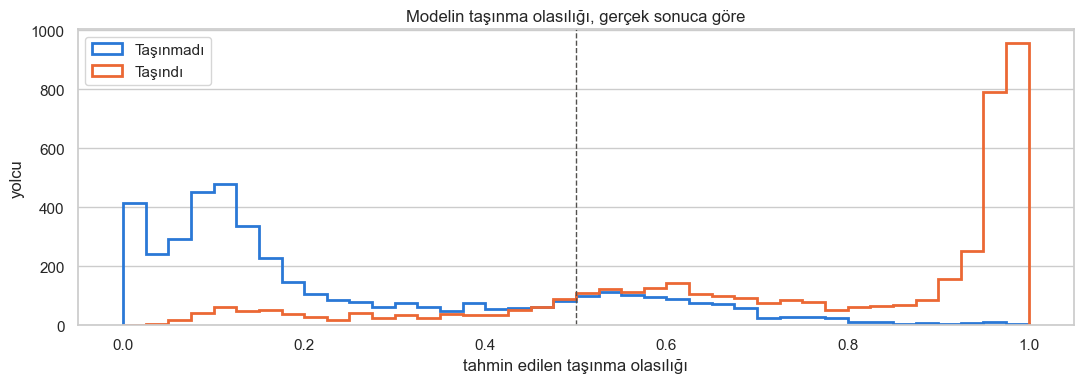

In [65]:
fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(0, 1, 41)
for value in [0, 1]:
    ax.hist(err.loc[err["Transported"] == value, "proba"], bins=bins, histtype="step", linewidth=2,
            color=TARGET_COLORS[bool(value)], label=TARGET_LABELS[bool(value)])
ax.axvline(0.5, color=INK, linestyle="--", linewidth=1)
ax.set(title="Modelin taşınma olasılığı, gerçek sonuca göre", xlabel="tahmin edilen taşınma olasılığı", ylabel="yolcu")
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Hatalar hangi yolcularda yoğunlaşıyor?

In [66]:
err["durum"] = np.select(
    [err["CryoSleep"].fillna(False).astype(bool), err["TotalSpend"] == 0],
    ["uykuda", "uyanık, harcama yok"], "uyanık, harcama var",
)
overall = err["wrong"].mean() * 100


def error_by(col):
    g = err.groupby(col, observed=True)
    return pd.DataFrame({
        "yolcu": g.size(),
        "taşınma %": g["Transported"].mean() * 100,
        "hata %": g["wrong"].mean() * 100,
        "hataların payı %": g["wrong"].sum() / err["wrong"].sum() * 100,
    }).round(1)


print(f"Genel hata oranı: %{overall:.1f}  ({err['wrong'].sum()} yolcu)")
error_by("durum")

Genel hata oranı: %18.5  (1610 yolcu)


,yolcu,taşınma %,hata %,hataların payı %
durum,,,,
"uyanık, harcama var",5040,29.90,17.50,54.70
"uyanık, harcama yok",546,61.50,28.20,9.60
uykuda,3107,81.70,18.50,35.70


In [67]:
error_by("Deck")

,yolcu,taşınma %,hata %,hataların payı %
Deck,,,,
A,262,50.40,16.80,2.70
B,796,73.20,5.70,2.80
C,761,68.10,5.70,2.70
D,487,43.30,13.60,4.10
E,885,36.00,22.00,12.10
F,2810,44.00,15.90,27.80
G,2588,51.60,28.90,46.50
T,5,20.00,0.00,0.00


In [68]:
pd.concat({"gezegen": error_by("HomePlanet"), "yaş grubu": error_by("AgeGroup"), "taraf": error_by("Side")})

yolcu  taşınma %  hata %  hataların payı %
gezegen   Earth    4708      42.40   26.10             76.40
          Europa   2175      66.00    7.40              9.90
          Mars     1805      52.40   12.10             13.60
yaş grubu 0-4       466      76.80   23.40              6.80
          13-17     739      55.30   15.70              7.20
          18-25    2351      45.80   20.50             29.90
          26-40    2887      48.00   15.80             28.40
          41-60    1511      49.50   19.00             17.80
          5-12      340      60.60   28.50              6.00
          61+       220      47.30   13.60              1.90
taraf     P        4251      45.20   19.60             51.70
          S        4343      55.60   17.40             47.00

In [69]:
# En zor bölge: uyanık ve harcama yapmış yolcular. Harcama miktarına göre hata
spenders = err[err["durum"] == "uyanık, harcama var"].copy()
spenders["lüks harcama"] = pd.cut(spenders["LuxurySpend"], [-1, 0, 100, 500, 1500, np.inf], labels=["0", "1-100", "101-500", "501-1500", "1500+"])
g = spenders.groupby("lüks harcama", observed=True)
pd.DataFrame({"yolcu": g.size(), "taşınma %": g["Transported"].mean() * 100, "hata %": g["wrong"].mean() * 100}).round(1)

,yolcu,taşınma %,hata %
lüks harcama,,,
0,204,64.70,29.90
1-100,643,65.90,33.10
101-500,849,43.50,21.80
501-1500,2069,21.40,15.80
1500+,1275,10.70,7.50


### 7.3 Model hangi bilgilere dayanıyor?

**Permütasyon önemi:** bir sütunun değerleri yolcular arasında rastgele karıştırılıyor ve accuracy'nin ne kadar düştüğüne bakılıyor. Büyük düşüş, modelin o sütuna dayandığını gösteriyor. Ölçüm ayarlı CatBoost ile, ilk CV turunun 5 doğrulama kümesinde yapılıyor.

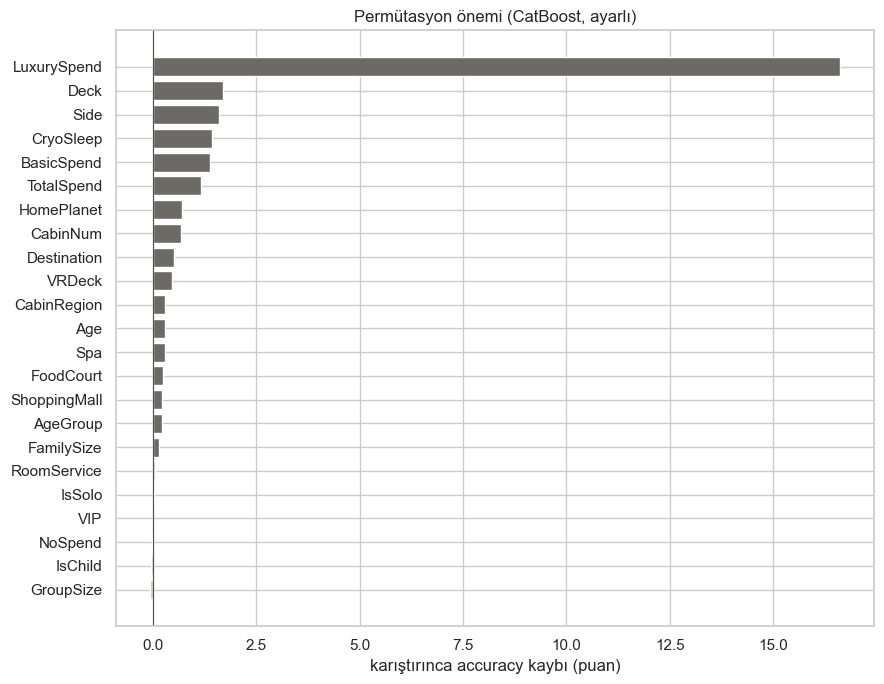

In [70]:
from sklearn.inspection import permutation_importance

X_frame = to_model_frame(X_fe_all, SPEC_ALL)
FEATURE_COLS = list(dict.fromkeys(sum(SPEC_ALL.values(), [])))
imps = []
for tr, va in SPLITS[:N_SPLITS]:
    pipe = Pipeline([("prep", make_preprocessor(SPEC_ALL)), ("model", build_model("CatBoost", tuning["CatBoost"]["params"]))])
    pipe.fit(X_frame.iloc[tr], y[tr])
    r = permutation_importance(pipe, X_frame.iloc[va], y[va], scoring="accuracy", n_repeats=5, random_state=0,
                               n_jobs=1)
    imps.append(pd.Series(r.importances_mean, index=X_frame.columns))
importance = (pd.concat(imps, axis=1).mean(axis=1) * 100).loc[FEATURE_COLS].sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance.index, importance.values, color=[NEUTRAL if v > 0.05 else "#c9c7bf" for v in importance.values])
ax.axvline(0, color=INK, linewidth=0.8)
ax.set(title="Permütasyon önemi (CatBoost, ayarlı)", xlabel="karıştırınca accuracy kaybı (puan)")
ax.grid(axis="x")
plt.tight_layout()
plt.show()

**Sonuç**

- **Hataların üçte ikisi modelin kararsız kaldığı yolcularda.** Olasılığı 0.3–0.7 arasında kalan 2501 yolcu, tüm hataların %67'sini oluşturuyor. Model "çok emin" olduğu 3644 yolcuda sadece %2.5 yanılıyor. Model neyi bilmediğinin farkında; eksik olan, kararsız yolcuları ayıracak bilgi.
- **Hataların %76'sı Earth'lü yolcularda.** Earth'lülerde hata oranı %26, Europa'lılarda %7. Güvertede aynı tablo: G güvertesi (tamamı Earth'lü) tüm hataların %47'si, hata oranı %29. B ve C güvertelerinde (Europa'lılar) hata sadece %6.
- **Uyuyan Earth'lüler zor bir grup.** 2.4'te uyuyan Europa'lıların %99'unun, uyuyan Earth'lülerin ise sadece %66'sının taşındığını görmüştük. Model uyuyan bir Earth'lünün taşınıp taşınmadığını ayırt edemiyor; uyuyanlarda hata oranı %18.5.
- **Az harcayan uyanıklar da zor.** Lüks harcaması 0–100 olan uyanıklarda hata %30–33, 1500 üstü harcayanlarda sadece %7.5.
- **Çocuklar:** 5–12 yaş %28.5, 0–4 yaş %23 hata.
- **Model en çok lüks harcamaya dayanıyor.** Bu sütun karıştırılınca accuracy 16.6 puan düşüyor. Ardından güverte, taraf, CryoSleep ve temel harcama geliyor (1.2–1.7 puan). Grup büyüklüğü, yalnızlık, VIP ve çocuk bayrağı sıfıra yakın; model bu bilgileri diğer sütunlardan zaten çıkarıyor.
- **CryoSleep neden bu kadar düşük görünüyor?** Permütasyon önemi, birbiriyle ilişkili sütunlarda yanıltıcı olabilir. CryoSleep karıştırılsa bile model aynı bilgiyi "hiç harcama yok" ve lüks harcama sütunlarından alabiliyor. Bu, CryoSleep'in önemsiz olduğu anlamına gelmiyor.

**Yeni özellikler için ipucu:** hatalar Earth'lülerde, özellikle G güvertesinde ve uyuyanlarda toplanıyor. Yeni bilgi, bu yolcuları kendi aralarında ayıracak bir şey olmalı.

### 7.4 Earth'lüleri ne ayırıyor?

Hataların çoğu Earth'lülerde, özellikle G güvertesinde. Burada kabin konumunu güverte, taraf ve uyku durumuyla birlikte inceliyoruz.

In [71]:
cab = err.copy()
cab["blok"] = pd.cut(cab["CabinNum"], [-1, 299, 599, 899, 1199, 1499, 1999],
                     labels=["0-299", "300-599", "600-899", "900-1199", "1200-1499", "1500+"])
for deck in ["G", "F"]:
    d = cab[cab["Deck"] == deck]
    table = d.pivot_table(index="blok", columns=["Side", "durum"], values="Transported", aggfunc="mean", observed=True) * 100
    print(f"\nGüverte {deck}: taşınma %")
    display(table.round(0))


Güverte G: taşınma %


Side                        P                                              S  \
durum     uyanık, harcama var uyanık, harcama yok uykuda uyanık, harcama var   
blok                                                                           
0-299                   24.00               54.00  60.00               22.00   
300-599                 18.00               44.00  62.00               21.00   
600-899                 19.00               35.00  59.00               45.00   
900-1199                32.00               48.00  61.00               68.00   
1200-1499               16.00               43.00  56.00               22.00   
1500+                   50.00                 NaN  50.00              100.00   

Side                                  
durum     uyanık, harcama yok uykuda  
blok                                  
0-299                   50.00  52.00  
300-599                 39.00  55.00  
600-899                 64.00  89.00  
900-1199                90.00  99.00  
1200-1499               59.00  66.00  
1500+                     NaN    NaN


Güverte F: taşınma %


Side                        P                                              S  \
durum     uyanık, harcama var uyanık, harcama yok uykuda uyanık, harcama var   
blok                                                                           
0-299                   29.00              100.00 100.00               25.00   
300-599                 20.00              100.00  97.00               21.00   
600-899                 21.00              100.00  98.00               47.00   
900-1199                23.00               88.00  97.00               48.00   
1200-1499               21.00               83.00  97.00               27.00   
1500+                   27.00               91.00 100.00               21.00   

Side                                  
durum     uyanık, harcama yok uykuda  
blok                                  
0-299                  100.00 100.00  
300-599                 67.00  94.00  
600-899                100.00 100.00  
900-1199               100.00 100.00  
1200-1499              100.00  95.00  
1500+                  100.00  96.00

In [72]:
lower = cab[cab["Deck"].isin(["F", "G"])]
pd.DataFrame({
    "yolcu": lower.groupby("HotZone").size(),
    "taşınma %": lower.groupby("HotZone")["Transported"].mean() * 100,
    "model hatası %": lower.groupby("HotZone")["wrong"].mean() * 100,
}).rename(index={0.0: "F/G, bölge dışı", 1.0: "F/G, sağ taraf 600–1199"}).round(1)

,yolcu,taşınma %,model hatası %
HotZone,,,
"F/G, bölge dışı",4413,42.50,24.00
"F/G, sağ taraf 600–1199",985,70.60,14.10


**Bulgu:** G güvertesinin sağ tarafında, 600–1199 numaralı kabinlerde uyuyanların %90–99'u taşınmış; aynı güvertenin başka yerlerinde %53–66. Harcama yapan uyanıklarda da oran bu bölgede 2–3 katına çıkıyor. F güvertesinde aynı bölge uyanıklarda görülüyor. Sol tarafta böyle bir bölge yok.

2.2'deki sağ taraf tepesi aslında **alt güvertelere özgü**. Adım 4'teki kabin bölgesi bu yüzden işe yaramamıştı: bölge ancak güverte × taraf × kabin numarası birleşince anlam kazanıyor. Bu bilgiyi tek bir sütunda veriyoruz: `HotZone`.

### 7.5 `HotZone` modele ne katıyor?

In [73]:
SPEC_HZ = extend(SPEC_ALL, {"bool": ["HotZone"]})
X_fe_all = fe[is_train]  # HotZone sütunu eklendi
PROBAS_HZ_PATH = TUNING_DIR / "split_probas_hotzone.pkl"
if PROBAS_HZ_PATH.exists():
    probas_hz = pickle.loads(PROBAS_HZ_PATH.read_bytes())
else:
    probas_hz = {n: split_probas(build_model(n, tuning[n]["params"]), SPEC_HZ) for n in TUNED_NAMES}
    PROBAS_HZ_PATH.write_bytes(pickle.dumps(probas_hz))

rows = []
pairs = [(n, probas[f"{n} (ayarlı)"], probas_hz[n]) for n in TUNED_NAMES]
pairs.append(("Ensemble: 4 boosting", blend(BOOSTED),
              [np.mean([probas_hz[n][i] for n in TUNED_NAMES], axis=0) for i in range(len(SPLITS))]))
for name, before_p, after_p in pairs:
    b, a = score_probas(before_p), score_probas(after_p)
    rows.append({"model": name, "önce %": b["accuracy"].mean() * 100, "HotZone ile %": a["accuracy"].mean() * 100,
                 "kazanç (puan)": (a["accuracy"].mean() - b["accuracy"].mean()) * 100,
                 "p": corrected_ttest(b["accuracy"], a["accuracy"]),
                 "F1 %": a["f1"].mean() * 100, "ROC AUC %": a["roc_auc"].mean() * 100})
hz_table = pd.DataFrame(rows).set_index("model").round(3)
hz_table

,önce %,HotZone ile %,kazanç (puan),p,F1 %,ROC AUC %
model,,,,,,
CatBoost,81.59,81.46,-0.12,0.55,81.71,90.86
LightGBM,81.32,81.37,0.05,0.77,81.61,90.69
XGBoost,81.16,81.20,0.04,0.86,81.61,90.54
HistGradientBoosting,81.31,81.38,0.06,0.81,81.76,90.72
Ensemble: 4 boosting,81.51,81.54,0.03,0.77,81.85,90.86


In [74]:
# Hatalar Earth'lülerde ve G güvertesinde azaldı mı?
ens_hz = [np.mean([probas_hz[n][i] for n in TUNED_NAMES], axis=0) for i in range(len(SPLITS))]
oof_hz = np.zeros((N_REPEATS, len(y)))
for i, ((tr, va), p) in enumerate(zip(SPLITS, ens_hz)):
    oof_hz[i // N_SPLITS, va] = p
err["wrong_hz"] = (oof_hz.mean(axis=0) >= 0.5).astype(int) != err["Transported"]

segments = {
    "tümü": err.index == err.index,
    "Earth": err["HomePlanet"] == "Earth",
    "G güvertesi": err["Deck"] == "G",
    "F güvertesi": err["Deck"] == "F",
    "HotZone içi": err["HotZone"] == 1,
    "Europa": err["HomePlanet"] == "Europa",
}
pd.DataFrame({
    name: {"yolcu": m.sum(), "hata % (önce)": err.loc[m, "wrong"].mean() * 100,
           "hata % (HotZone ile)": err.loc[m, "wrong_hz"].mean() * 100,
           "hatalı yolcu (önce)": err.loc[m, "wrong"].sum(), "hatalı yolcu (sonra)": err.loc[m, "wrong_hz"].sum()}
    for name, m in segments.items()
}).T.round(1)

,yolcu,hata % (önce),hata % (HotZone ile),hatalı yolcu (önce),hatalı yolcu (sonra)
tümü,"8,693.00",18.50,18.60,"1,610.00","1,614.00"
Earth,"4,708.00",26.10,26.20,"1,230.00","1,233.00"
G güvertesi,"2,588.00",28.90,28.80,748.00,745.00
F güvertesi,"2,810.00",15.90,16.00,448.00,450.00
HotZone içi,985.00,14.10,14.20,139.00,140.00
Europa,"2,175.00",7.40,7.30,160.00,159.00


In [75]:
path, checks = make_submission([build_model(n, tuning[n]["params"]) for n in TUNED_NAMES], SPEC_HZ,
                               "04_ensemble_hotzone.csv")
prev = pd.read_csv(SUBMISSION_DIR / "03_ensemble_4_boosting.csv")["Transported"]
checks["03 ile aynı tahmin %"] = round((pd.read_csv(path)["Transported"] == prev).mean() * 100, 1)
checks

satır sayısı (beklenen 4277)          4277
sütunlar sample ile aynı              True
PassengerId sırası sample ile aynı    True
değerler True/False                   True
eksik değer                              0
taşındı tahmini %                    52.60
03 ile aynı tahmin %                 98.50
dtype: object

**Sonuç: `HotZone` hiçbir şey katmadı, çünkü model bu bölgeyi zaten biliyordu.**

- Tüm modellerde fark −0.12 ile +0.06 puan arasında ve hiçbiri anlamlı değil (p = 0.55–0.86). Ensemble 81.51'den 81.54'e çıktı: 8693 yolcuda toplam 4 yolcu fark.
- Önceki tablodaki ipucu gözümüzden kaçmıştı: modelin hata oranı bölge içinde %14, bölge dışında %24. Ağaç modelleri güverte, taraf ve kabin numarasından bu bölgeyi zaten kendileri bulmuştu. Keşifte gördüğümüz desen modelin **zaten bildiği** bir şeydi; yeni bilgi değildi.
- **Hatalar nerede kalıyor?** G güvertesinde bölge dışındaki uyuyan Earth'lülerin %52–66'sı taşınmış. Bu yolcular kabin, yaş, varış noktası ve grup bakımından birbirinden ayırt edilemiyor; sonuçları elimizdeki bilgiyle yazı tura gibi. Model burada gerçekten tahmin edilemeyen bir belirsizliğe dayanıyor.
- `04_ensemble_hotzone.csv` 03 ile %98.5 aynı tahmini veriyor. Leaderboard'da fark görmeyi beklemiyoruz.
- **Ders:** keşifte görülen güçlü bir desen, modelin henüz bilmediği bir şey değilse skoru artırmaz. Yeni bir özellik eklemeden önce, modelin o desende gerçekten yanılıp yanılmadığına bakmak gerekiyor.

## Epilog: Veri Ne Söyledi, Ne Söyleyemedi

**Söyledikleri.** Spaceship Titanic'te kimin taşındığını iki şey belirliyor: yolcunun çarpışma anında **ne yaptığı** ve **nerede olduğu**.

- Kapsülünde uyuyanların %82'si taşındı, gemide dolaşıp harcama yapanların %30'u.
- Harcamanın türü de önemli: oda servisi, spa ve VR güvertesinde çok harcayanlarda oran %5'e kadar düşüyor.
- Konum ikinci belirleyici: B ve C güverteleri (%68–73), geminin sağ tarafı (%56) ve alt güvertelerde sağ taraftaki 600–1199 numaralı kabinler (%71).
- Europa'dan gelenler (%66) Earth'ten gelenlerden (%42) daha çok taşındı, ama bu büyük ölçüde hangi güvertede kaldıklarının bir yansıması.
- Küçük çocuklar ayrı bir grup: 0–4 yaşındakilerin %77'si taşındı, yetişkinlerde oran %46–50.

**Söyleyemedikleri.** Model %18.5 oranında yanılıyor ve bu hataların %76'sı Earth'lü yolcularda, özellikle G güvertesinde. Bu yolcuların çoğu uyuyordu ve taşınma oranları %52–66 arasında. Kabin numarası, yaş, varış noktası, grup, aile: hiçbiri bu insanları birbirinden ayırmıyor. Elimizdeki veriyle bu yolcuların sonucu yazı tura.

**Ne işe yaradı, ne yaramadı.** Beş şey denedik ve sadece biri işe yaradı:

| Deneme | Sonuç |
|---|---|
| Harcamaları lüks ve temel diye ayırmak | ✅ Doğrusal modelde +1.8 puan |
| Kurallı eksik doldurma (%73–100 doğru) | ❌ Eksik oranı sadece %2 olduğu için skoru değiştirmedi |
| Grup, aile, yaş, kabin bölgesi özellikleri | ❌ Ağaç modelleri bu bilgiyi ham sütunlardan zaten çıkarıyor |
| Optuna ile ayar araması | ❌ Arama CV'sinde +0.3 puan, bağımsız bölmelerde ~0 |
| Ensemble ve `HotZone` | ❌ Modeller zaten %94–95 aynı tahmini veriyor |

Bu projenin asıl dersi bu: **skoru modelin ayarı değil, modele verilen bilginin yeni olup olmadığı belirliyor.** Keşifte bulduğumuz her güçlü desen modele yeni bir şey öğretmiyor; çoğunu zaten biliyordu.

**Sonuç.** En iyi Kaggle skoru **0.81038** (dört ayarlı gradient boosting modelinin ortalaması). Cross-validation %81.51 demişti; aradaki 0.5 puanlık fark, leaderboard'un yalnızca yaklaşık 2100 yolcuyla hesaplanmasından gelen oynamanın içinde. `HotZone` eklenmiş sürüm 0.80851 aldı; beklendiği gibi fark yaratmadı.

### Kaggle için son adım

Kaggle'ın "Submit" düğmesi çıktı klasörünün kökündeki dosyaları gösterir. En iyi modelin (dört ayarlı boosting modelinin ortalaması, public skor 0.81038) tahminini `submission.csv` adıyla oraya yazıyoruz.

In [76]:
import shutil

BEST_SUBMISSION = SUBMISSION_DIR / "03_ensemble_4_boosting.csv"
shutil.copy(BEST_SUBMISSION, "submission.csv")

sample = pd.read_csv(DATA_DIR / "sample_submission.csv")
saved_sub = pd.read_csv("submission.csv")
pd.Series({
    "kaynak": BEST_SUBMISSION.name,
    "satır sayısı (beklenen 4277)": len(saved_sub),
    "sütunlar sample ile aynı": list(saved_sub.columns) == list(sample.columns),
    "PassengerId sırası sample ile aynı": saved_sub["PassengerId"].equals(sample["PassengerId"]),
    "taşındı tahmini %": round(saved_sub["Transported"].mean() * 100, 1),
}, dtype=object)

kaynak                                03_ensemble_4_boosting.csv
satır sayısı (beklenen 4277)                                4277
sütunlar sample ile aynı                                    True
PassengerId sırası sample ile aynı                          True
taşındı tahmini %                                          52.30
dtype: object